# Sensitivity Analysis — 432 Core Scenarios

5D full factorial: bat_scale × bat_duration × gas_price × co2_price × climate_year

**Sections:**
1. Load results overview
2. LMP sensitivity (DE00 annual average price)
3. ANOVA — variance decomposition
4. Battery analysis (scale × duration)
5. Interaction effects
6. Climate year comparison
7. Storage revenue (implicit arbitrage profit)

In [4]:
import sys
!{sys.executable} -m pip install pyarrow

In [13]:
import sys
sys.path.insert(0, "../grid-model")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pypsa
from pathlib import Path

SOLVED_DIR    = Path("../solved_networks_core")
RESULTS_CSV   = SOLVED_DIR / "solve_results.csv"
PREPROCESSED  = Path("../data/tyndp2024/preprocessed/solved")

plt.rcParams["figure.dpi"] = 130
plt.rcParams["font.size"] = 10

In [14]:
# Load all preprocessed parquets (run once — fast)
lmp_raw      = pd.read_parquet(PREPROCESSED / "lmp.parquet")
storage_p_raw = pd.read_parquet(PREPROCESSED / "storage_p.parquet")
static_su    = pd.read_parquet(PREPROCESSED / "static_storage_units.parquet")
static_gen   = pd.read_parquet(PREPROCESSED / "static_generators.parquet")

lmp_raw["timestamp"]       = pd.to_datetime(lmp_raw["timestamp"])
storage_p_raw["timestamp"] = pd.to_datetime(storage_p_raw["timestamp"])

# Battery unit names and their bus mapping
bat_units  = static_su[static_su.carrier == "battery"].index.tolist()
bat_cols   = [c for c in storage_p_raw.columns if c in bat_units]
bat_bus    = static_su.loc[bat_units, "bus"]          # Series: unit → bus

# DE00 battery units
de00_bat_cols = [c for c in bat_cols if bat_bus.get(c) == "DE00"]

# Europe-wide average LMP per (tag, timestamp)
lmp_eu_avg = (
    lmp_raw.set_index(["tag", "timestamp"])
    .mean(axis=1)
    .rename("lmp_eu_avg")
    .reset_index()
)

print(f"LMP shape:       {lmp_raw.shape}  — buses: {lmp_raw.shape[1]-2}")
print(f"Storage P shape: {storage_p_raw.shape}  — units: {storage_p_raw.shape[1]-2}")
print(f"Battery units:   {len(bat_cols)}  (DE00: {len(de00_bat_cols)})")

LMP shape:       (3784320, 57)  — buses: 55
Storage P shape: (3784320, 121)  — units: 119
Battery units:   35  (DE00: 1)


## Section 1 — Results Overview

In [15]:
df = pd.read_csv(RESULTS_CSV)

print(f"Total scenarios: {len(df)}")
print(f"Solved:  {(df.status == 'solved').sum()}")
print(f"Failed:  {(df.status != 'solved').sum()}")
print()
print("Solve time stats (seconds):")
print(df[df.status == 'solved']['solve_time_s'].describe().round(1).to_string())
print()
print("Slack > 1000 MWh:", (df['slack_mwh'] > 1000).sum(), "scenarios")
print("Slack = 0:        ", (df['slack_mwh'] == 0).sum(), "scenarios")

df.head(3)

Total scenarios: 432
Solved:  432
Failed:  0

Solve time stats (seconds):
count    432.0
mean     514.1
std       28.3
min      443.4
25%      494.7
50%      513.8
75%      533.0
max      599.7

Slack > 1000 MWh: 432 scenarios
Slack = 0:         0 scenarios


,tag,climate_year,gas_price,co2_price,battery_scale,load_scale,ntc_scale,battery_duration,nuclear_scale,battery_extendable,matrix,scenario_id,output_file,status,consistency_warnings,termination_condition,objective,slack_mwh,solve_time_s
0,bat1x_gas18_co2_80_cy2003_dur1x,2003,18.0,80.0,1,1.0,1.0,1,1.0,False,core,0,/Users/radovanhodor/Documents/TUKE/Final diplo...,solved,NaN,optimal,5.091463e+10,376749.4,521.4
1,bat1x_gas18_co2_80_cy2003_dur2x,2003,18.0,80.0,1,1.0,1.0,2,1.0,False,core,1,/Users/radovanhodor/Documents/TUKE/Final diplo...,solved,NaN,optimal,5.012831e+10,316227.5,530.8
2,bat1x_gas18_co2_80_cy2003_dur3x,2003,18.0,80.0,1,1.0,1.0,3,1.0,False,core,2,/Users/radovanhodor/Documents/TUKE/Final diplo...,solved,NaN,optimal,4.976269e+10,295134.7,535.9


## Section 2 — LMP Sensitivity (DE00 annual average price)

Load all solved networks and extract DE00 annual average LMP.

In [16]:
BUS = "DE00"

lmp_raw["month"] = lmp_raw["timestamp"].dt.month
winter_mask = lmp_raw["month"].isin([12, 1, 2])
summer_mask = lmp_raw["month"].isin([6, 7, 8])

lmp_annual = lmp_raw.groupby("tag")[BUS].mean().rename("lmp_annual")
lmp_winter = lmp_raw[winter_mask].groupby("tag")[BUS].mean().rename("lmp_winter")
lmp_summer = lmp_raw[summer_mask].groupby("tag")[BUS].mean().rename("lmp_summer")

meta = pd.read_csv(RESULTS_CSV)
solved = meta[meta.status == "solved"].copy()

res = (
    solved
    .rename(columns={
        "battery_scale":    "bat_scale",
        "battery_duration": "bat_duration",
        "gas_price":        "gas_price",
        "co2_price":        "co2_price",
        "climate_year":     "climate_year",
    })
    .set_index("tag")
    .join(lmp_annual)
    .join(lmp_winter)
    .join(lmp_summer)
    .reset_index()
)

print(f"Done. LMP range: {res.lmp_annual.min():.1f} – {res.lmp_annual.max():.1f} EUR/MWh")
res.head(3)

Done. LMP range: 47.3 – 97.5 EUR/MWh


,tag,climate_year,gas_price,co2_price,bat_scale,load_scale,ntc_scale,bat_duration,nuclear_scale,battery_extendable,...,output_file,status,consistency_warnings,termination_condition,objective,slack_mwh,solve_time_s,lmp_annual,lmp_winter,lmp_summer
0,bat1x_gas18_co2_80_cy2003_dur1x,2003,18.0,80.0,1,1.0,1.0,1,1.0,False,...,/Users/radovanhodor/Documents/TUKE/Final diplo...,solved,NaN,optimal,5.091463e+10,376749.4,521.4,61.828888,109.334877,43.314304
1,bat1x_gas18_co2_80_cy2003_dur2x,2003,18.0,80.0,1,1.0,1.0,2,1.0,False,...,/Users/radovanhodor/Documents/TUKE/Final diplo...,solved,NaN,optimal,5.012831e+10,316227.5,530.8,61.218777,106.083801,43.930775
2,bat1x_gas18_co2_80_cy2003_dur3x,2003,18.0,80.0,1,1.0,1.0,3,1.0,False,...,/Users/radovanhodor/Documents/TUKE/Final diplo...,solved,NaN,optimal,4.976269e+10,295134.7,535.9,61.402092,106.082443,44.475574


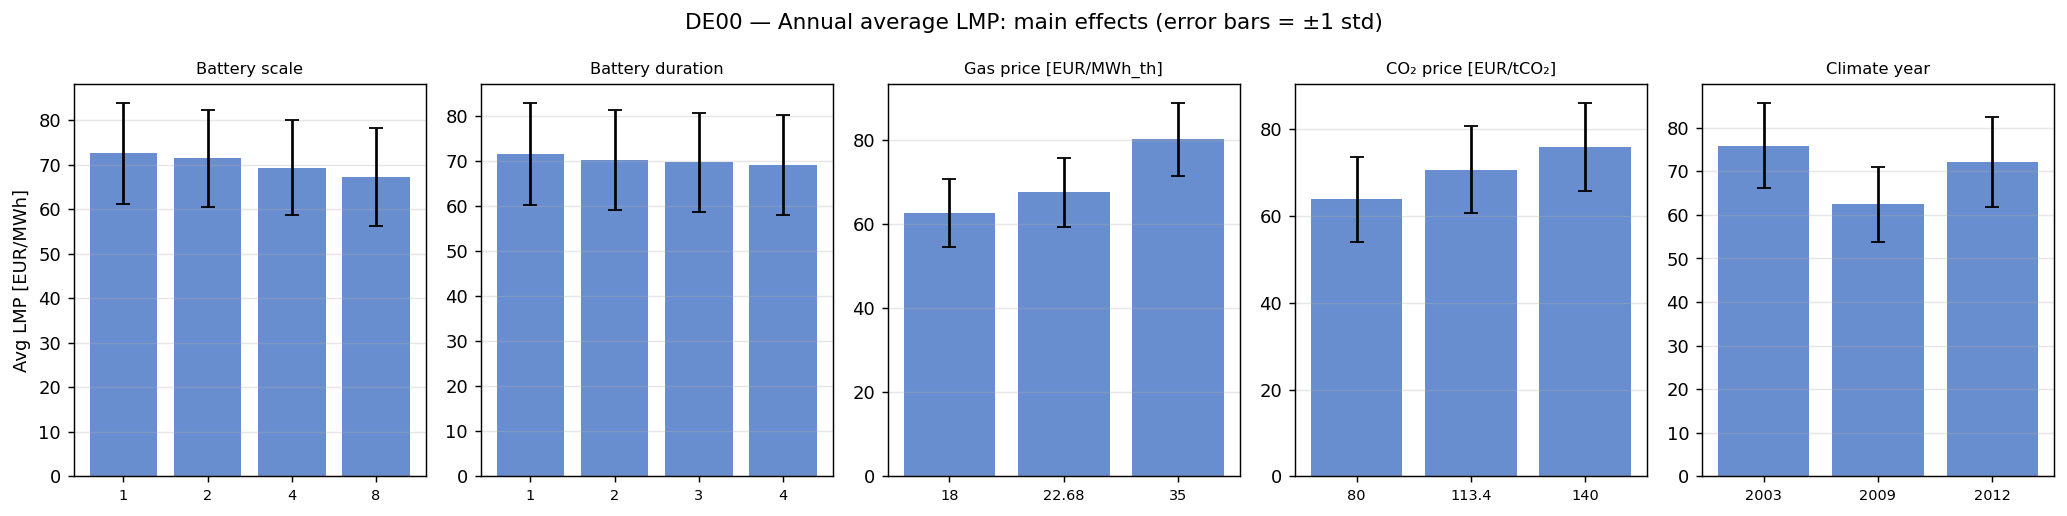

In [17]:
# Main effects: average LMP by each parameter level
params = {
    "bat_scale":    [1, 2, 4, 8],
    "bat_duration": [1, 2, 3, 4],
    "gas_price":    [18, 22.68, 35],
    "co2_price":    [80, 113.4, 140],
    "climate_year": [2003, 2009, 2012],
}
labels = {
    "bat_scale":    "Battery scale",
    "bat_duration": "Battery duration",
    "gas_price":    "Gas price [EUR/MWh_th]",
    "co2_price":    "CO₂ price [EUR/tCO₂]",
    "climate_year": "Climate year",
}

fig, axes = plt.subplots(1, 5, figsize=(16, 4))
for ax, (param, levels) in zip(axes, params.items()):
    means = [res[res[param] == lvl]["lmp_annual"].mean() for lvl in levels]
    stds  = [res[res[param] == lvl]["lmp_annual"].std()  for lvl in levels]
    ax.bar(range(len(levels)), means, yerr=stds, capsize=4, color="#4472c4", alpha=0.8)
    ax.set_xticks(range(len(levels)))
    ax.set_xticklabels([str(l) for l in levels], fontsize=8)
    ax.set_title(labels[param], fontsize=9)
    ax.set_ylabel("Avg LMP [EUR/MWh]" if ax == axes[0] else "")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle(f"{BUS} — Annual average LMP: main effects (error bars = ±1 std)", fontsize=12)
plt.tight_layout()
plt.show()

## Section 3 — ANOVA: Variance Decomposition

Which parameter explains the most variance in DE00 LMP?

In [22]:
print(res.shape)
print(res.lmp_annual.isna().sum(), "NaN out of", len(res))
print(res[["tag","bat_scale","lmp_annual"]].head(3))
print("\nlmp_raw columns:", lmp_raw.columns.tolist()[:5])

(432, 22)
0 NaN out of 432
                               tag  bat_scale  lmp_annual
0  bat1x_gas18_co2_80_cy2003_dur1x          1   61.828888
1  bat1x_gas18_co2_80_cy2003_dur2x          1   61.218777
2  bat1x_gas18_co2_80_cy2003_dur3x          1   61.402092

lmp_raw columns: ['tag', 'timestamp', 'AL00', 'AT00', 'BA00']


In [25]:
print("lmp_raw tags:", lmp_raw["tag"].nunique())
print("storage_p tags:", storage_p_raw["tag"].nunique())
print("lmp_raw shape:", lmp_raw.shape)
print("storage_p shape:", storage_p_raw.shape)
print("lmp_raw buses:", lmp_raw.shape[1] - 2)
print("battery units:", len(bat_cols))
print("DE00 battery units:", len(de00_bat_cols))
print("\nSample tags:")
print(lmp_raw["tag"].unique()[:3])


lmp_raw tags: 432
storage_p tags: 432
lmp_raw shape: (3784320, 58)
storage_p shape: (3784320, 121)
lmp_raw buses: 56
battery units: 35
DE00 battery units: 1

Sample tags:
['bat1x_gas18_co2_80_cy2003_dur1x' 'bat1x_gas18_co2_80_cy2003_dur2x'
 'bat1x_gas18_co2_80_cy2003_dur3x']


Grand mean LMP: 70.17 EUR/MWh
Total SS: 53330.5

             Parameter       SS  Var explained %  F-stat  p-value
Gas price [EUR/MWh_th] 23591.05            44.24  170.15     0.00
          Climate year 14016.96            26.28   76.48     0.00
  CO₂ price [EUR/tCO₂] 10433.04            19.56   52.17     0.00
         Battery scale  1751.78             3.28    4.85     0.00
      Battery duration   374.03             0.70    1.01     0.39


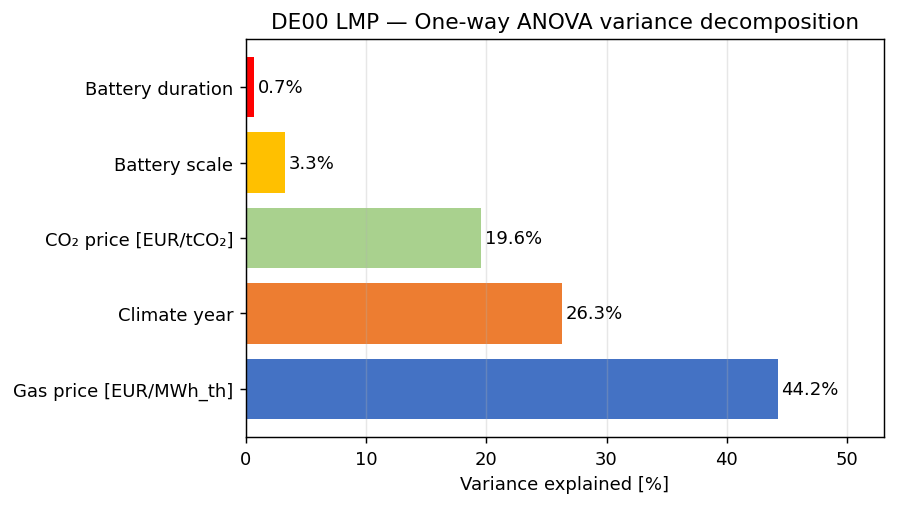

In [26]:
from scipy import stats

grand_mean = res["lmp_annual"].mean()
ss_total = ((res["lmp_annual"] - grand_mean) ** 2).sum()

anova_rows = []
for param, levels in params.items():
    groups = [res[res[param] == lvl]["lmp_annual"].values for lvl in levels]
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    f_stat, p_val = stats.f_oneway(*groups)
    anova_rows.append({
        "Parameter": labels[param],
        "SS": ss_between,
        "Var explained %": 100 * ss_between / ss_total,
        "F-stat": f_stat,
        "p-value": p_val,
    })

anova_df = pd.DataFrame(anova_rows).sort_values("Var explained %", ascending=False)
print(f"Grand mean LMP: {grand_mean:.2f} EUR/MWh")
print(f"Total SS: {ss_total:.1f}")
print()
print(anova_df.to_string(index=False, float_format="{:.2f}".format))

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#4472c4", "#ed7d31", "#a9d18e", "#ffc000", "#ff0000"]
bars = ax.barh(anova_df["Parameter"], anova_df["Var explained %"], color=colors[:len(anova_df)])
for bar, val in zip(bars, anova_df["Var explained %"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, f"{val:.1f}%", va="center")
ax.set_xlabel("Variance explained [%]")
ax.set_title(f"{BUS} LMP — One-way ANOVA variance decomposition")
ax.grid(axis="x", alpha=0.3)
ax.set_xlim(0, anova_df["Var explained %"].max() * 1.2)
plt.tight_layout()
plt.show()

## Section 4 — Battery Analysis: Scale × Duration Heatmap

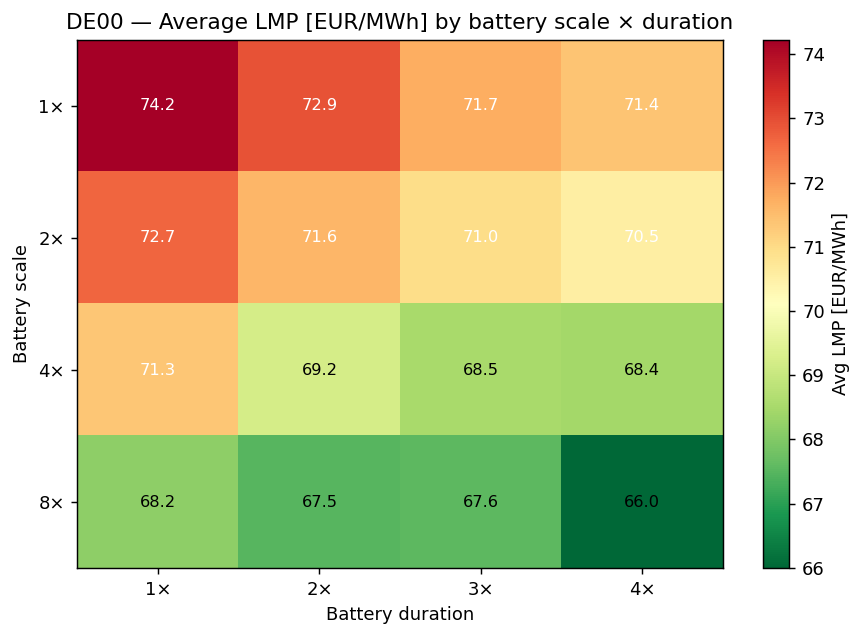

In [27]:
# Heatmap: bat_scale × bat_duration → average LMP (averaged over gas, co2, cy)
scales    = [1, 2, 4, 8]
durations = [1, 2, 3, 4]

matrix = np.zeros((len(scales), len(durations)))
for i, s in enumerate(scales):
    for j, d in enumerate(durations):
        val = res[(res.bat_scale == s) & (res.bat_duration == d)]["lmp_annual"].mean()
        matrix[i, j] = val

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(matrix, cmap="RdYlGn_r", aspect="auto")
plt.colorbar(im, ax=ax, label="Avg LMP [EUR/MWh]")

ax.set_xticks(range(len(durations)))
ax.set_yticks(range(len(scales)))
ax.set_xticklabels([f"{d}×" for d in durations])
ax.set_yticklabels([f"{s}×" for s in scales])
ax.set_xlabel("Battery duration")
ax.set_ylabel("Battery scale")
ax.set_title(f"{BUS} — Average LMP [EUR/MWh] by battery scale × duration")

for i in range(len(scales)):
    for j in range(len(durations)):
        ax.text(j, i, f"{matrix[i,j]:.1f}", ha="center", va="center", fontsize=9,
                color="white" if matrix[i,j] > matrix.mean() else "black")

plt.tight_layout()
plt.show()

## Section 5 — Interaction Effects: gas_price × co2_price

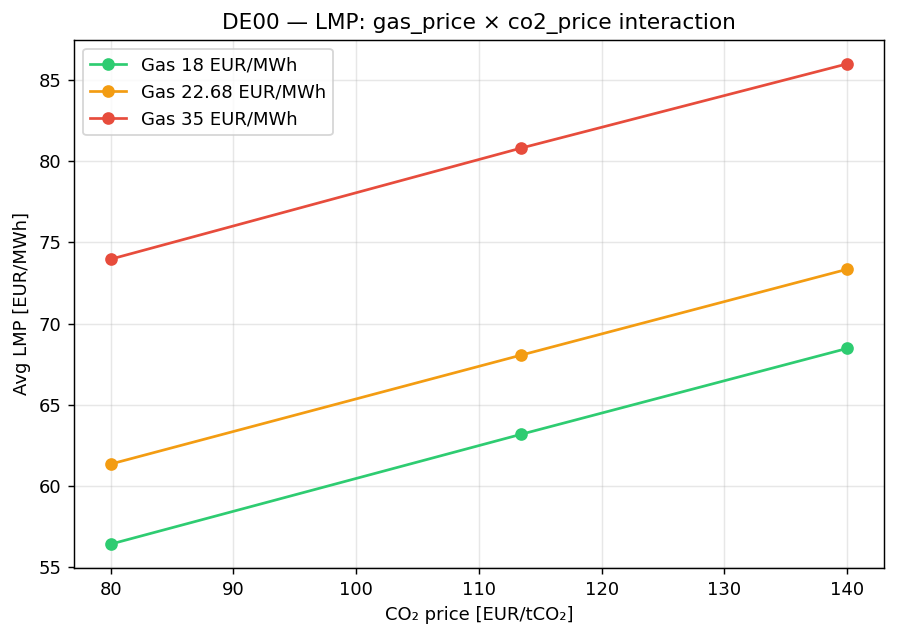

In [28]:
gas_prices = [18, 22.68, 35]
co2_prices = [80, 113.4, 140]

fig, ax = plt.subplots(figsize=(7, 5))
colors_gas = ["#2ecc71", "#f39c12", "#e74c3c"]

for gas_p, color in zip(gas_prices, colors_gas):
    means = [res[(res.gas_price == gas_p) & (res.co2_price == co2_p)]["lmp_annual"].mean()
             for co2_p in co2_prices]
    ax.plot(co2_prices, means, marker="o", color=color, label=f"Gas {gas_p} EUR/MWh")

ax.set_xlabel("CO₂ price [EUR/tCO₂]")
ax.set_ylabel("Avg LMP [EUR/MWh]")
ax.set_title(f"{BUS} — LMP: gas_price × co2_price interaction")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Section 6 — Climate Year Comparison

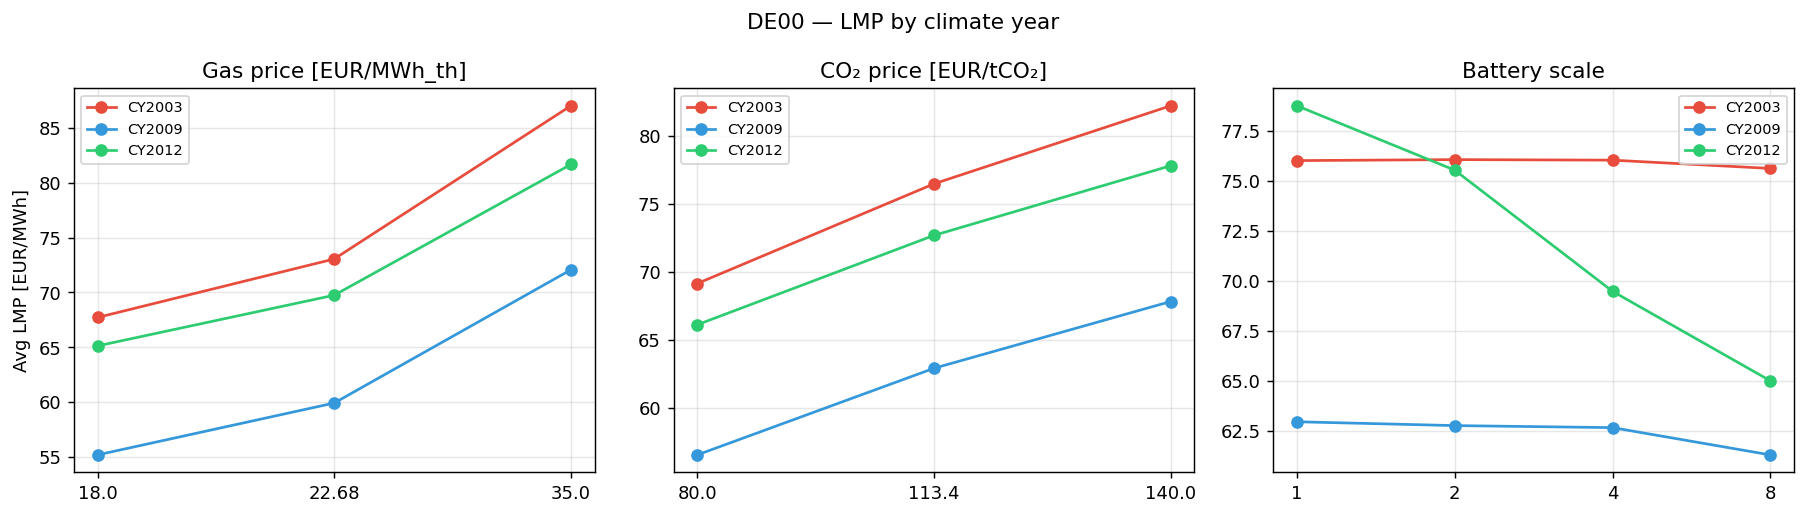


DE00 average LMP by climate year:
  CY2003: mean=75.9  min=60.2  max=93.9 EUR/MWh
  CY2009: mean=62.4  min=47.3  max=78.5 EUR/MWh
  CY2012: mean=72.2  min=48.4  max=97.5 EUR/MWh


In [29]:
cy_colors = {2003: "#e74c3c", 2009: "#3498db", 2012: "#2ecc71"}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, param in zip(axes, ["gas_price", "co2_price", "bat_scale"]):
    levels = sorted(res[param].unique())
    for cy, color in cy_colors.items():
        means = [res[(res.climate_year == cy) & (res[param] == lvl)]["lmp_annual"].mean()
                 for lvl in levels]
        ax.plot(range(len(levels)), means, marker="o", color=color, label=f"CY{cy}")
    ax.set_xticks(range(len(levels)))
    ax.set_xticklabels([str(l) for l in levels])
    ax.set_title(labels[param])
    ax.set_ylabel("Avg LMP [EUR/MWh]" if ax == axes[0] else "")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle(f"{BUS} — LMP by climate year", fontsize=12)
plt.tight_layout()
plt.show()

# Summary table
print(f"\n{BUS} average LMP by climate year:")
for cy in [2003, 2009, 2012]:
    lmps = res[res.climate_year == cy]["lmp_annual"]
    print(f"  CY{cy}: mean={lmps.mean():.1f}  min={lmps.min():.1f}  max={lmps.max():.1f} EUR/MWh")

## Section 7 — Storage Revenue (Implicit Arbitrage Profit)

Revenue = Σ(p_discharge × LMP) − Σ(p_charge × LMP)

Computed for a subset of networks to compare storage types and scenarios.

In [30]:
# Storage revenue by carrier for baseline subset (gas=22.68, co2=113.4, bat_scale=1, dur=1, all CYs)
baseline_tags = res[
    (res.bat_scale == 1) & (res.bat_duration == 1) &
    (res.gas_price == 22.68) & (res.co2_price == 113.4)
].sort_values("climate_year")["tag"].tolist()

# All storage units and their carriers/buses
all_su_cols = [c for c in storage_p_raw.columns if c not in ("tag", "timestamp")]
su_carrier  = static_su.loc[[c for c in all_su_cols if c in static_su.index], "carrier"]
su_bus      = static_su.loc[[c for c in all_su_cols if c in static_su.index], "bus"]

for tag in baseline_tags:
    cy = res[res.tag == tag]["climate_year"].values[0]

    sp  = storage_p_raw[storage_p_raw.tag == tag].set_index("timestamp")[all_su_cols]
    lmp = lmp_raw[lmp_raw.tag == tag].set_index("timestamp")

    revenues = {}
    for su in all_su_cols:
        if su not in su_bus.index:
            continue
        bus = su_bus[su]
        if bus not in lmp.columns:
            continue
        revenues[su] = float((sp[su] * lmp[bus]).sum())

    rev_series   = pd.Series(revenues)
    rev_by_carrier = rev_series.groupby(su_carrier.reindex(rev_series.index)).sum() / 1e6
    print(f"\nCY{int(cy)} — Storage revenue by carrier [M EUR/year]:")
    print(rev_by_carrier.sort_values(ascending=False).round(1).to_string())


CY2003 — Storage revenue by carrier [M EUR/year]:
carrier
hydro-reservoir    15938.9
hydro-phs           2651.8
hydro-phs-pure      2572.9
battery             1627.0
hydro-pondage        787.5

CY2009 — Storage revenue by carrier [M EUR/year]:
carrier
hydro-reservoir    16060.5
hydro-phs           2850.5
hydro-phs-pure      2000.1
battery             1455.2
hydro-pondage        931.7

CY2012 — Storage revenue by carrier [M EUR/year]:
carrier
hydro-reservoir    13437.8
hydro-phs-pure      3746.0
hydro-phs           3563.5
battery             2177.0
hydro-pondage        870.4


## Section 8 — Battery Buy/Sell Prices & Revenue across All Scenarios

> **Note:** This section loads all 432 networks again. To optimize, merge with Section 2 loop so each network is loaded only once.

In [31]:
# EU-wide battery buy/sell prices and revenue — all 432 scenarios from parquet
bat_p = storage_p_raw[["tag", "timestamp"] + bat_cols].copy()
bat_p["p_eu"] = bat_p[bat_cols].sum(axis=1)

merged = bat_p[["tag", "timestamp", "p_eu"]].merge(lmp_eu_avg, on=["tag", "timestamp"])

bat_records = []
for tag, grp in merged.groupby("tag"):
    p   = grp["p_eu"]
    lmp = grp["lmp_eu_avg"]
    row = res[res.tag == tag].iloc[0]

    charge_mask    = p < -0.1
    discharge_mask = p >  0.1

    buy_price  = float((lmp[charge_mask] * (-p[charge_mask])).sum() / (-p[charge_mask]).sum()) if charge_mask.any() else None
    sell_price = float((lmp[discharge_mask] * p[discharge_mask]).sum() / p[discharge_mask].sum()) if discharge_mask.any() else None
    revenue    = float((p * lmp).sum()) / 1e6
    energy_in  = float((-p[charge_mask]).sum()) / 1e6
    energy_out = float(p[discharge_mask].sum()) / 1e6

    bat_records.append({
        "tag":           tag,
        "bat_scale":     row["bat_scale"],
        "bat_duration":  row["bat_duration"],
        "gas_price":     row["gas_price"],
        "co2_price":     row["co2_price"],
        "climate_year":  row["climate_year"],
        "buy_price":     buy_price,
        "sell_price":    sell_price,
        "spread":        (sell_price - buy_price) if sell_price and buy_price else None,
        "revenue_meur":  revenue,
        "energy_in_twh":  energy_in,
        "energy_out_twh": energy_out,
    })

bat_df = pd.DataFrame(bat_records)
print(f"Done. Battery revenue range: {bat_df.revenue_meur.min():.0f} – {bat_df.revenue_meur.max():.0f} M EUR/year")
print(f"Buy price:  {bat_df.buy_price.mean():.1f} EUR/MWh (avg)")
print(f"Sell price: {bat_df.sell_price.mean():.1f} EUR/MWh (avg)")
print(f"Spread:     {bat_df.spread.mean():.1f} EUR/MWh (avg)")

Done. Battery revenue range: 599 – 2363 M EUR/year
Buy price:  52.4 EUR/MWh (avg)
Sell price: 75.3 EUR/MWh (avg)
Spread:     22.8 EUR/MWh (avg)


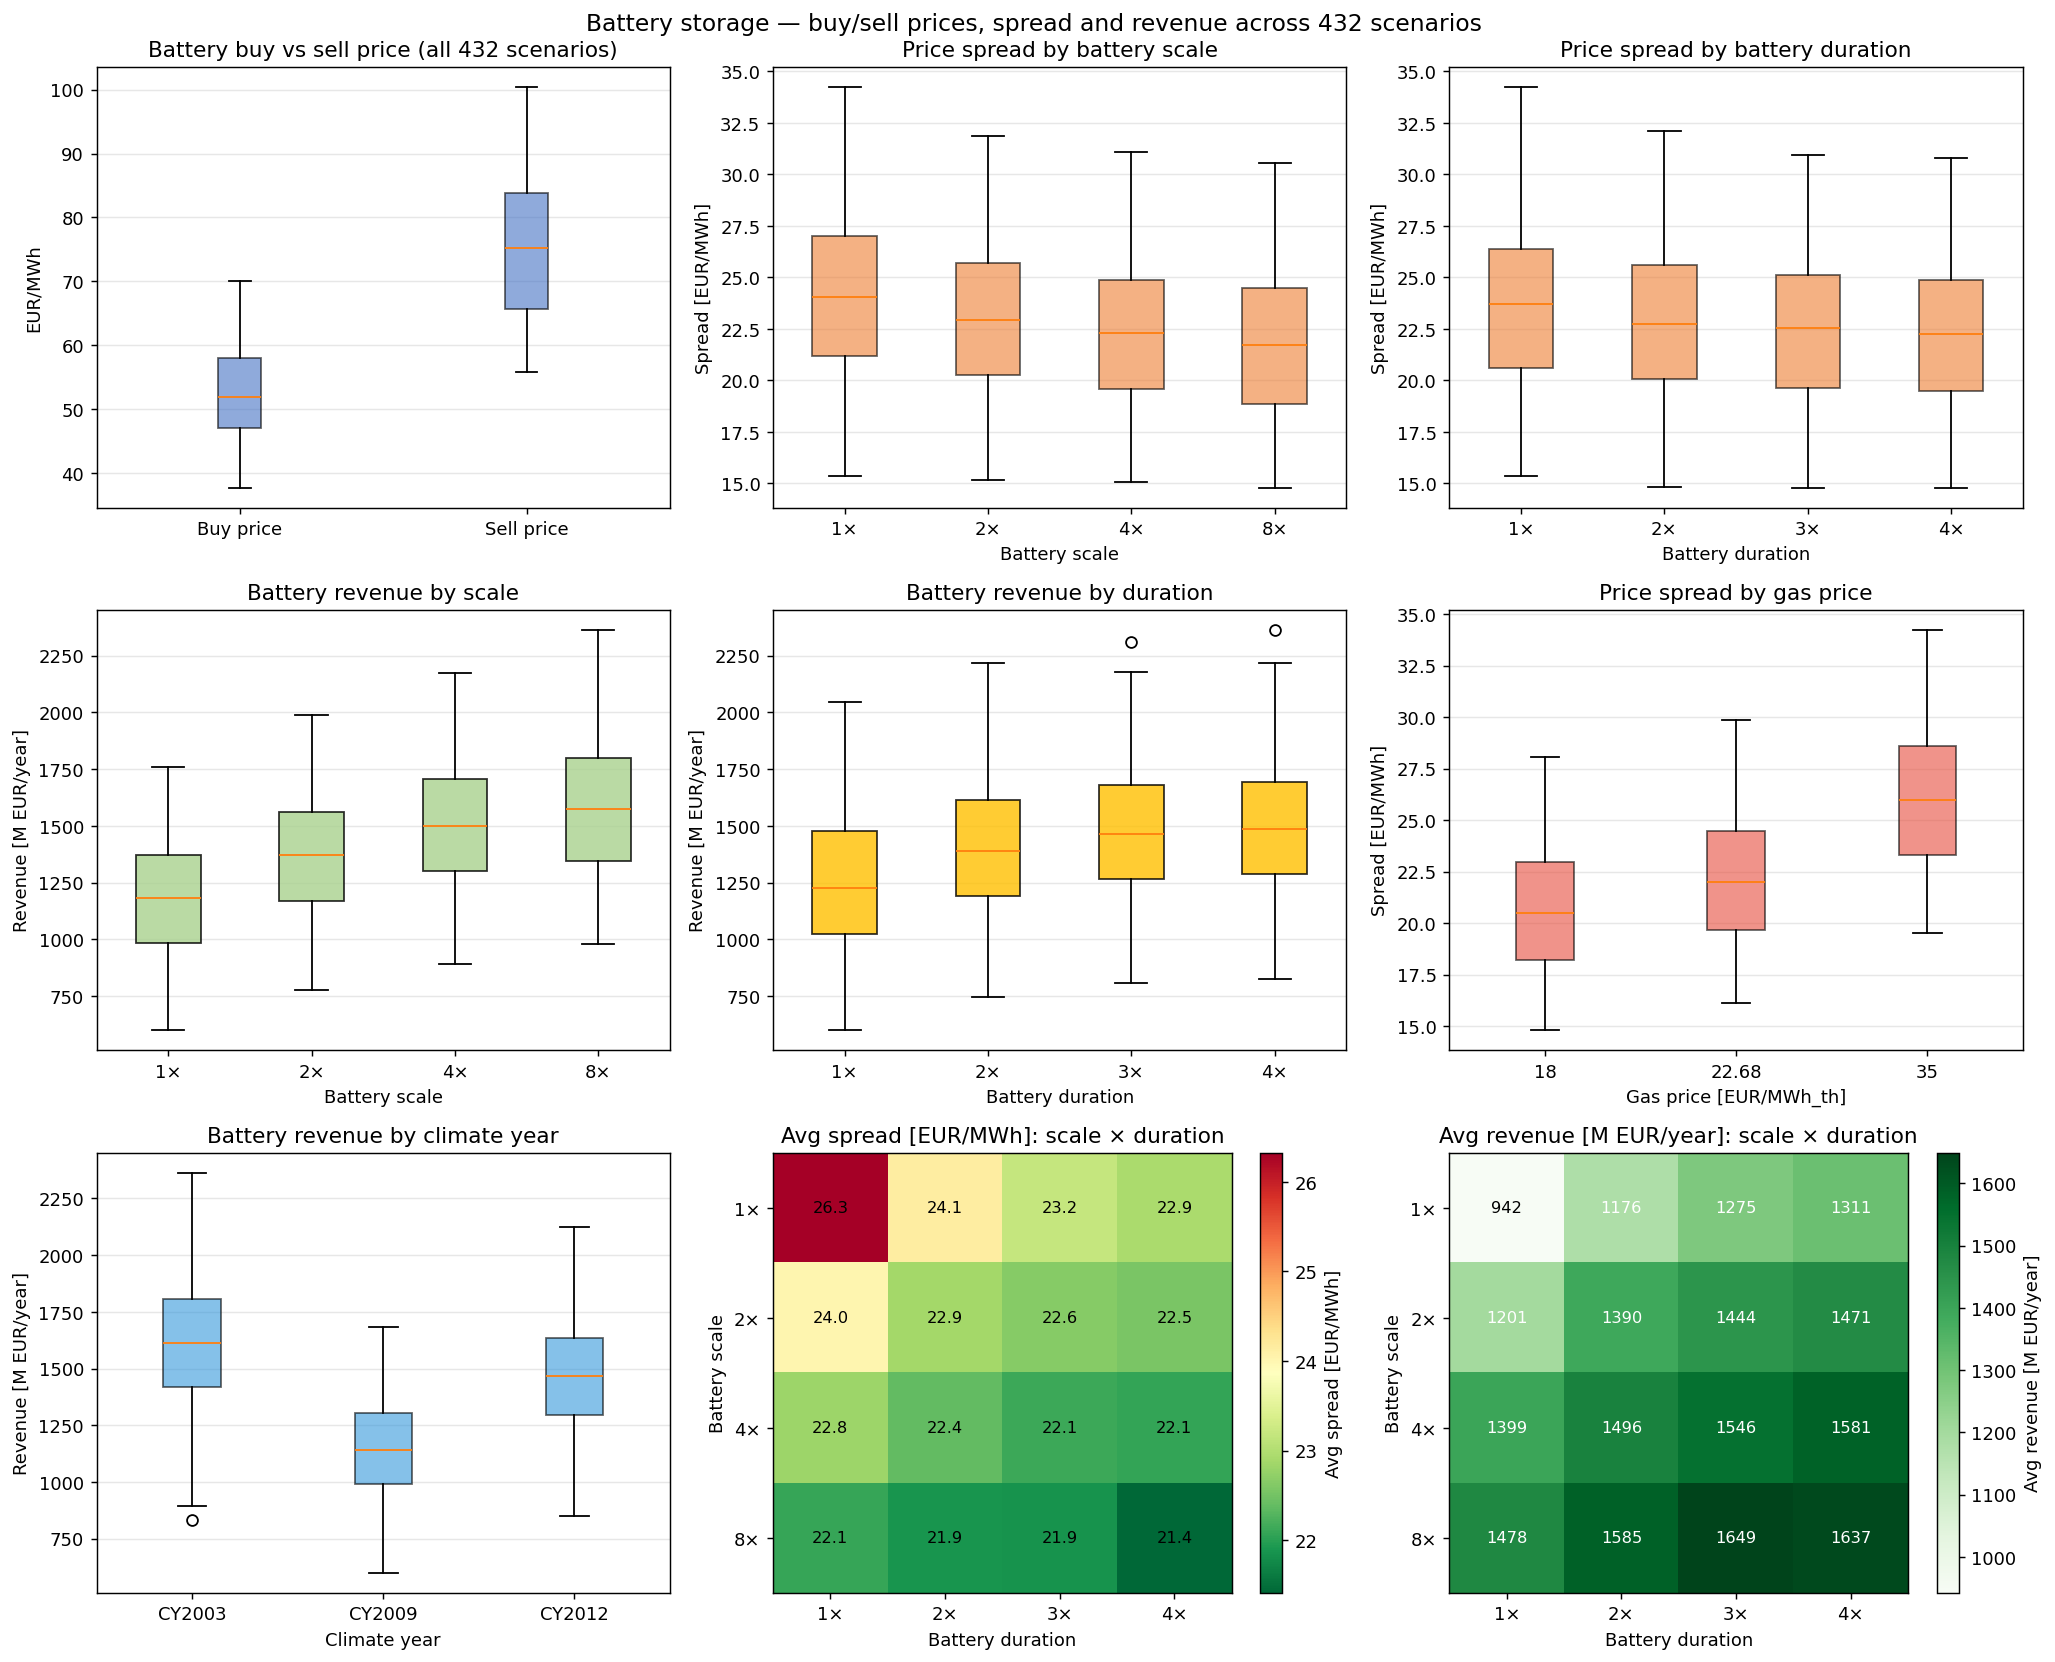

Battery revenue summary by scale:
           buy_price  sell_price  spread  revenue_meur
bat_scale                                             
1               51.1        75.2    24.1        1176.0
2               52.3        75.3    23.0        1376.4
4               53.0        75.3    22.4        1505.5
8               53.4        75.2    21.8        1587.0


In [32]:
fig, axes = plt.subplots(3, 3, figsize=(16, 13))

# 1. Boxplot: buy/sell price distribution
ax = axes[0, 0]
ax.boxplot([bat_df.buy_price.dropna(), bat_df.sell_price.dropna()],
           labels=["Buy price", "Sell price"], patch_artist=True,
           boxprops=dict(facecolor="#4472c4", alpha=0.6))
ax.set_ylabel("EUR/MWh")
ax.set_title("Battery buy vs sell price (all 432 scenarios)")
ax.grid(axis="y", alpha=0.3)

# 2. Spread by bat_scale
ax = axes[0, 1]
scales = [1, 2, 4, 8]
data = [bat_df[bat_df.bat_scale == s]["spread"].dropna() for s in scales]
ax.boxplot(data, labels=[f"{s}×" for s in scales], patch_artist=True,
           boxprops=dict(facecolor="#ed7d31", alpha=0.6))
ax.set_xlabel("Battery scale")
ax.set_ylabel("Spread [EUR/MWh]")
ax.set_title("Price spread by battery scale")
ax.grid(axis="y", alpha=0.3)

# 3. Spread by bat_duration
ax = axes[0, 2]
durations = [1, 2, 3, 4]
data = [bat_df[bat_df.bat_duration == d]["spread"].dropna() for d in durations]
ax.boxplot(data, labels=[f"{d}×" for d in durations], patch_artist=True,
           boxprops=dict(facecolor="#ed7d31", alpha=0.6))
ax.set_xlabel("Battery duration")
ax.set_ylabel("Spread [EUR/MWh]")
ax.set_title("Price spread by battery duration")
ax.grid(axis="y", alpha=0.3)

# 4. Revenue by bat_scale
ax = axes[1, 0]
data = [bat_df[bat_df.bat_scale == s]["revenue_meur"].dropna() for s in scales]
ax.boxplot(data, labels=[f"{s}×" for s in scales], patch_artist=True,
           boxprops=dict(facecolor="#a9d18e", alpha=0.8))
ax.set_xlabel("Battery scale")
ax.set_ylabel("Revenue [M EUR/year]")
ax.set_title("Battery revenue by scale")
ax.grid(axis="y", alpha=0.3)

# 5. Revenue by bat_duration
ax = axes[1, 1]
data = [bat_df[bat_df.bat_duration == d]["revenue_meur"].dropna() for d in durations]
ax.boxplot(data, labels=[f"{d}×" for d in durations], patch_artist=True,
           boxprops=dict(facecolor="#ffc000", alpha=0.8))
ax.set_xlabel("Battery duration")
ax.set_ylabel("Revenue [M EUR/year]")
ax.set_title("Battery revenue by duration")
ax.grid(axis="y", alpha=0.3)

# 6. Spread by gas_price
ax = axes[1, 2]
gas_prices = [18, 22.68, 35]
data = [bat_df[bat_df.gas_price == g]["spread"].dropna() for g in gas_prices]
ax.boxplot(data, labels=[str(g) for g in gas_prices], patch_artist=True,
           boxprops=dict(facecolor="#e74c3c", alpha=0.6))
ax.set_xlabel("Gas price [EUR/MWh_th]")
ax.set_ylabel("Spread [EUR/MWh]")
ax.set_title("Price spread by gas price")
ax.grid(axis="y", alpha=0.3)

# 7. Revenue by climate year
ax = axes[2, 0]
cys = [2003, 2009, 2012]
data = [bat_df[bat_df.climate_year == cy]["revenue_meur"].dropna() for cy in cys]
ax.boxplot(data, labels=[f"CY{cy}" for cy in cys], patch_artist=True,
           boxprops=dict(facecolor="#3498db", alpha=0.6))
ax.set_xlabel("Climate year")
ax.set_ylabel("Revenue [M EUR/year]")
ax.set_title("Battery revenue by climate year")
ax.grid(axis="y", alpha=0.3)

# 8. Heatmapa: scale x duration -> spread
ax = axes[2, 1]
matrix = np.zeros((len(scales), len(durations)))
for i, s in enumerate(scales):
    for j, d in enumerate(durations):
        matrix[i, j] = bat_df[(bat_df.bat_scale == s) & (bat_df.bat_duration == d)]["spread"].mean()
im = ax.imshow(matrix, cmap="RdYlGn_r", aspect="auto")
plt.colorbar(im, ax=ax, label="Avg spread [EUR/MWh]")
ax.set_xticks(range(len(durations)))
ax.set_yticks(range(len(scales)))
ax.set_xticklabels([f"{d}×" for d in durations])
ax.set_yticklabels([f"{s}×" for s in scales])
ax.set_xlabel("Battery duration")
ax.set_ylabel("Battery scale")
ax.set_title("Avg spread [EUR/MWh]: scale × duration")
for i in range(len(scales)):
    for j in range(len(durations)):
        ax.text(j, i, f"{matrix[i,j]:.1f}", ha="center", va="center", fontsize=9)

# 9. Heatmapa: scale x duration -> revenue
ax = axes[2, 2]
matrix_rev = np.zeros((len(scales), len(durations)))
for i, s in enumerate(scales):
    for j, d in enumerate(durations):
        matrix_rev[i, j] = bat_df[(bat_df.bat_scale == s) & (bat_df.bat_duration == d)]["revenue_meur"].mean()
im2 = ax.imshow(matrix_rev, cmap="Greens", aspect="auto")
plt.colorbar(im2, ax=ax, label="Avg revenue [M EUR/year]")
ax.set_xticks(range(len(durations)))
ax.set_yticks(range(len(scales)))
ax.set_xticklabels([f"{d}×" for d in durations])
ax.set_yticklabels([f"{s}×" for s in scales])
ax.set_xlabel("Battery duration")
ax.set_ylabel("Battery scale")
ax.set_title("Avg revenue [M EUR/year]: scale × duration")
for i in range(len(scales)):
    for j in range(len(durations)):
        ax.text(j, i, f"{matrix_rev[i,j]:.0f}", ha="center", va="center", fontsize=9,
                color="white" if matrix_rev[i,j] > matrix_rev.max()*0.6 else "black")

fig.suptitle("Battery storage — buy/sell prices, spread and revenue across 432 scenarios", fontsize=13)
plt.tight_layout()
plt.show()

print("Battery revenue summary by scale:")
print(bat_df.groupby("bat_scale")[["buy_price","sell_price","spread","revenue_meur"]].mean().round(1).to_string())


## Section 9 — Battery Installed Capacity by Scale × Duration

Static analysis — loads 16 networks (4 scale × 4 duration, fixed gas/co2/cy).
Shows total EU capacity [GW / GWh] and per-bus breakdown.

In [34]:
# Battery installed capacity by scale × duration — from static_storage_units + manifest
# (network structure is identical across scenarios, only dispatch changes)
FIX_GAS = 22.68
FIX_CO2 = 113.4
FIX_CY  = 2009
SCALES    = [1, 2, 4, 8]
DURATIONS = [1, 2, 3, 4]

manifest = pd.read_parquet(PREPROCESSED / "manifest.parquet")
bats = static_su[static_su.carrier == "battery"].copy()

cap_records = []
bus_records = []

for s in SCALES:
    for d in DURATIONS:
        tag = manifest[
            (manifest.battery_scale == s) & (manifest.battery_duration == d) &
            (manifest.gas_price == FIX_GAS) & (manifest.co2_price == FIX_CO2) &
            (manifest.climate_year == FIX_CY)
        ]["tag"].values
        if len(tag) == 0:
            print(f"Missing: scale={s} dur={d}")
            continue
        tag = tag[0]

        # static_storage_units is from the first network — p_nom is scaled
        # we need to load one .nc per scale×duration to get actual p_nom
        # (bat_scale changes p_nom, bat_duration changes max_hours)
        # Load from solved network
        nc_path = SOLVED_DIR / f"{tag}.nc"
        if not nc_path.exists():
            print(f"Missing .nc: {tag}")
            continue
        n = pypsa.Network()
        n.import_from_netcdf(str(nc_path))
        b = n.storage_units[n.storage_units.carrier == "battery"]

        total_mw  = b.p_nom.sum() / 1e3
        total_mwh = (b.p_nom * b.max_hours).sum() / 1e3
        cap_records.append({
            "bat_scale": s, "bat_duration": d,
            "total_gw":  round(total_mw, 1),
            "total_gwh": round(total_mwh, 1),
            "avg_hours": round(total_mwh / total_mw, 2) if total_mw > 0 else None,
        })
        per_bus = b.groupby("bus").agg(
            mw  =("p_nom", "sum"),
            mwh =("p_nom", lambda x: (x * b.loc[x.index, "max_hours"]).sum())
        ) / 1e3
        per_bus["bat_scale"] = s
        per_bus["bat_duration"] = d
        bus_records.append(per_bus.reset_index())

cap_df = pd.DataFrame(cap_records)
bus_df = pd.concat(bus_records, ignore_index=True)

print("=== Total EU battery capacity [GW] ===")
print(cap_df.pivot(index="bat_scale", columns="bat_duration", values="total_gw").to_string())
print()
print("=== Total EU battery energy [GWh] ===")
print(cap_df.pivot(index="bat_scale", columns="bat_duration", values="total_gwh").to_string())
print()
print("=== Average duration [h] ===")
print(cap_df.pivot(index="bat_scale", columns="bat_duration", values="avg_hours").to_string())

INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'TYNDP2024_Electricity_2030' has buses, carriers, generators, links, loads, storage_units, sub_networks
INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'TYNDP2024_Electricity_2030' has buses, carriers, generators, links, loads, storage_units, sub_networks
INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'TYNDP2024_Electricity_2030' has buses, carriers, generators, links, loads, storage_units, sub_networks
INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'TYNDP2024_Electricity_2030' has buses, carriers, generators, links, loads, storage_units, sub_networks
INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'TYNDP2024_Electricity_2030' has buses, carriers,

=== Total EU battery capacity [GW] ===
bat_duration      1      2      3      4
bat_scale                               
1              62.3   62.3   62.3   62.3
2             124.7  124.7  124.7  124.7
4             249.3  249.3  249.3  249.3
8             498.6  498.6  498.6  498.6

=== Total EU battery energy [GWh] ===
bat_duration       1       2       3       4
bat_scale                                   
1              208.0   336.7   418.1   461.8
2              416.0   673.3   836.2   923.6
4              832.0  1346.7  1672.3  1847.2
8             1664.1  2693.4  3344.6  3694.4

=== Average duration [h] ===
bat_duration     1    2     3     4
bat_scale                          
1             3.34  5.4  6.71  7.41
2             3.34  5.4  6.71  7.41
4             3.34  5.4  6.71  7.41
8             3.34  5.4  6.71  7.41


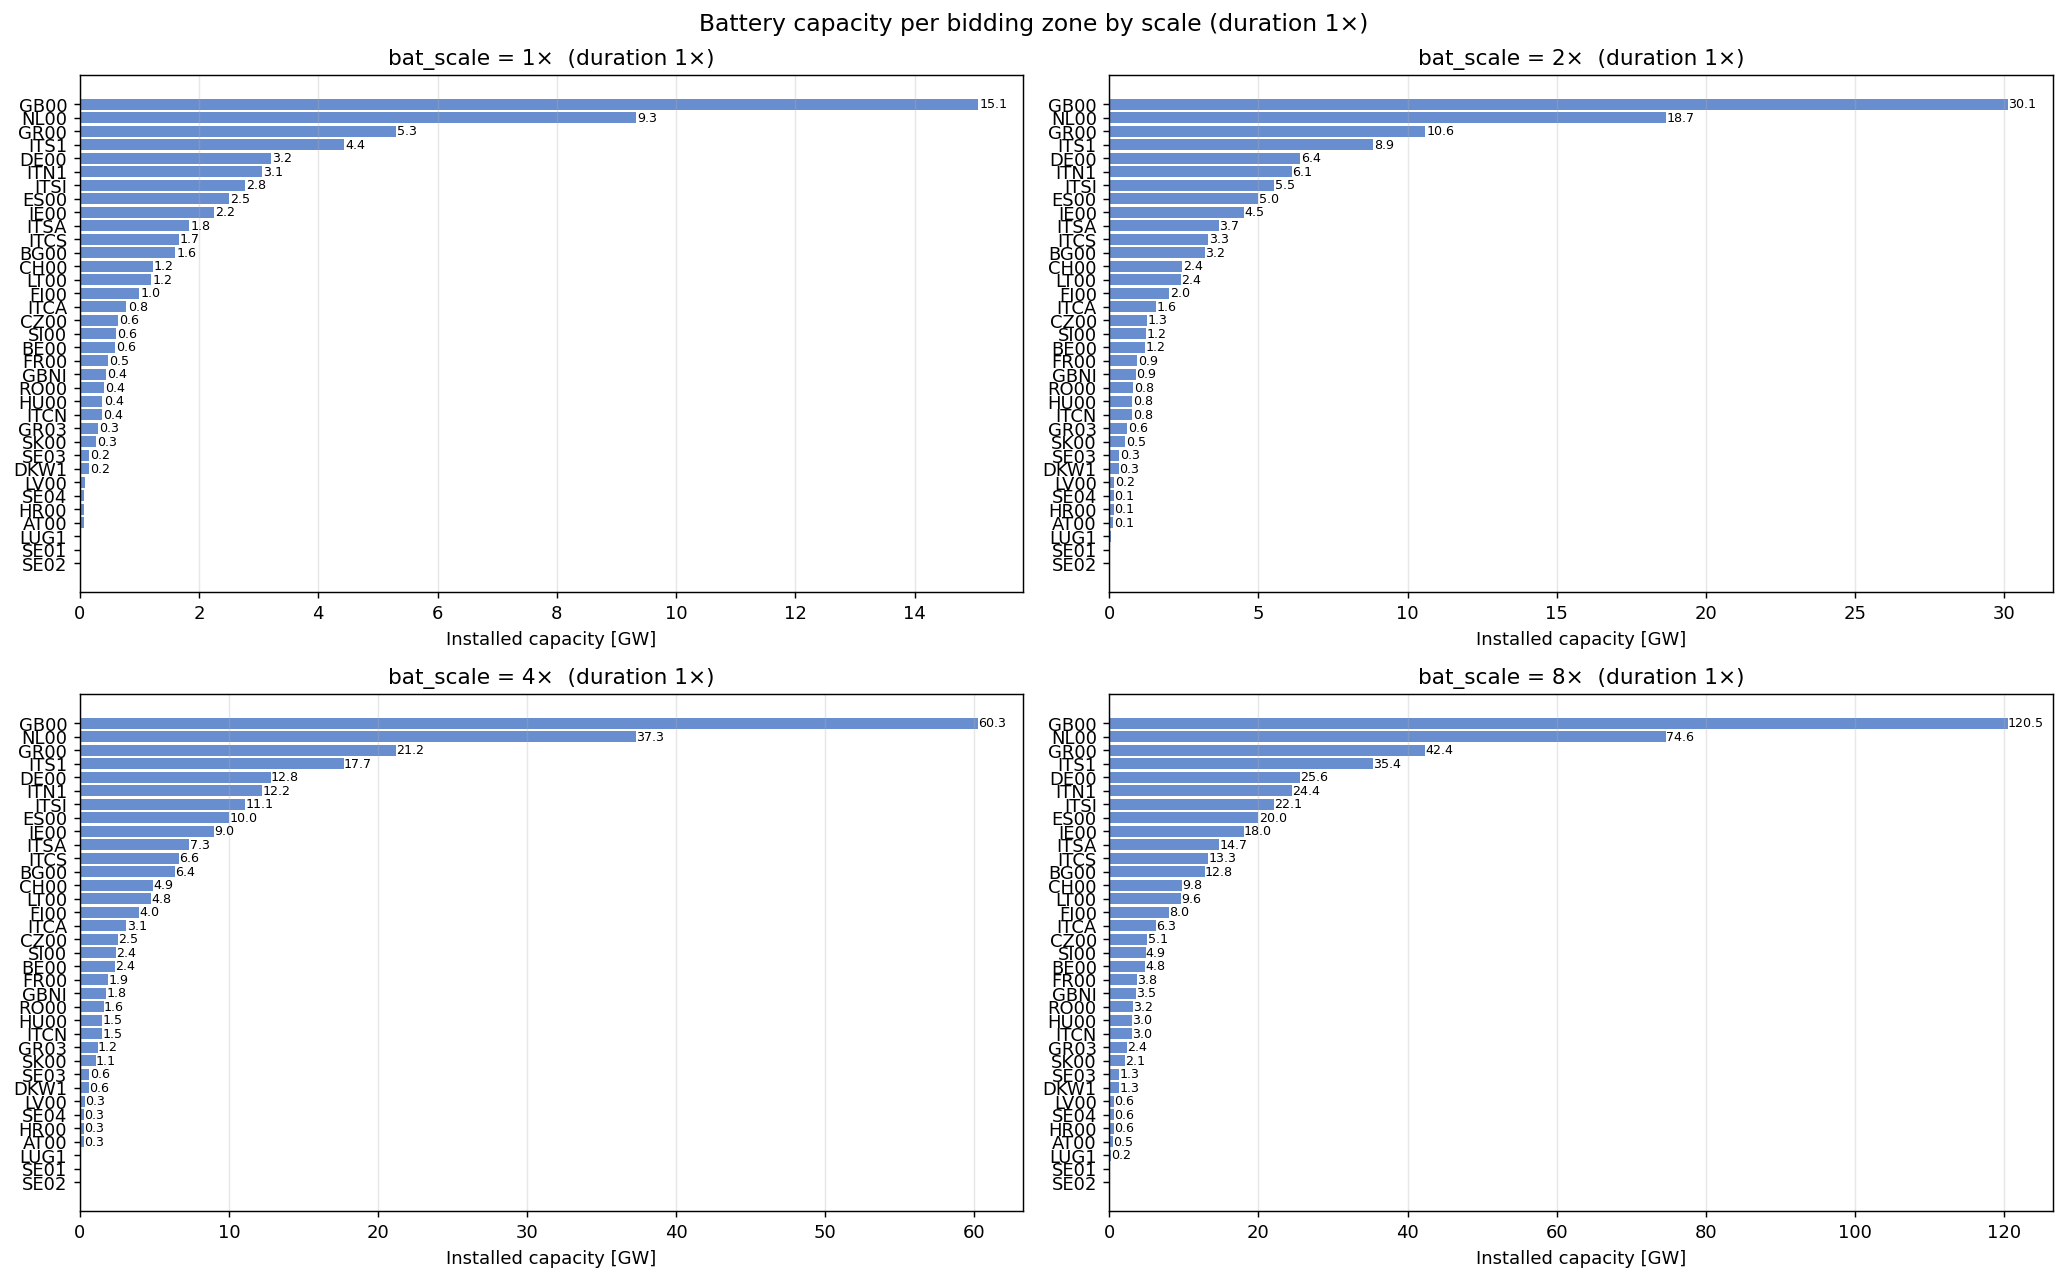

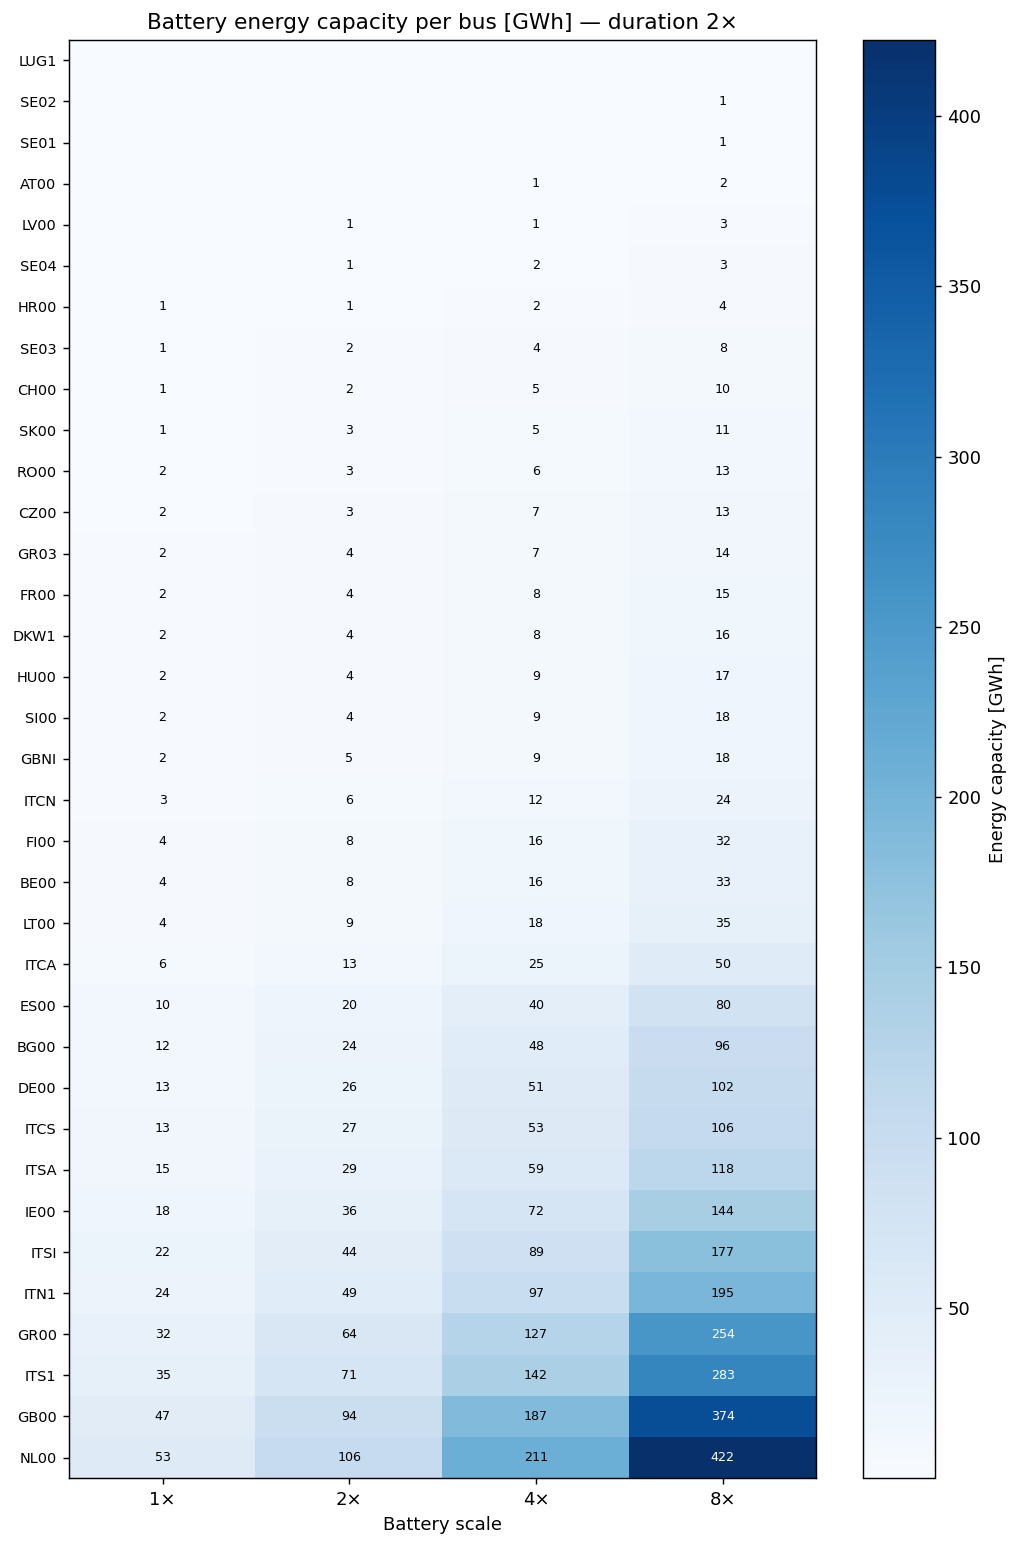

In [35]:
# Per-bus capacity for each bat_scale (fixed duration=1x)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, s in zip(axes, SCALES):
    sub = bus_df[(bus_df.bat_scale == s) & (bus_df.bat_duration == 1)].sort_values("mw", ascending=True)
    ax.barh(sub["bus"], sub["mw"], color="#4472c4", alpha=0.8)
    ax.set_title(f"bat_scale = {s}×  (duration 1×)")
    ax.set_xlabel("Installed capacity [GW]")
    ax.grid(axis="x", alpha=0.3)
    for i, (_, row) in enumerate(sub.iterrows()):
        if row["mw"] > 0.1:
            ax.text(row["mw"] + 0.02, i, f"{row['mw']:.1f}", va="center", fontsize=7)

fig.suptitle("Battery capacity per bidding zone by scale (duration 1×)", fontsize=13)
plt.tight_layout()
plt.show()

# Heatmap: GWh per bus × bat_scale (fixed duration=2x)
pivot = bus_df[bus_df.bat_duration == 2].pivot_table(
    index="bus", columns="bat_scale", values="mwh", aggfunc="sum"
).fillna(0).sort_values(4, ascending=True)

fig, ax = plt.subplots(figsize=(8, 12))
im = ax.imshow(pivot.values, cmap="Blues", aspect="auto")
plt.colorbar(im, ax=ax, label="Energy capacity [GWh]")
ax.set_xticks(range(len(SCALES)))
ax.set_xticklabels([f"{s}×" for s in SCALES])
ax.set_yticks(range(len(pivot)))
ax.set_yticklabels(pivot.index, fontsize=8)
ax.set_xlabel("Battery scale")
ax.set_title("Battery energy capacity per bus [GWh] — duration 2×")
for i in range(len(pivot)):
    for j in range(len(SCALES)):
        val = pivot.values[i, j]
        if val > 0.5:
            ax.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=7,
                    color="white" if val > pivot.values.max()*0.6 else "black")
plt.tight_layout()
plt.show()


## Section 8b — Battery Analysis for DE00 only

In [36]:
# DE00 battery buy/sell prices and revenue — all 432 scenarios from parquet
BUS_FILTER = "DE00"

de_p = storage_p_raw[["tag", "timestamp"] + de00_bat_cols].copy()
de_p["p_de00"] = de_p[de00_bat_cols].sum(axis=1)

lmp_de00_ts = lmp_raw[["tag", "timestamp", BUS_FILTER]].rename(columns={BUS_FILTER: "lmp_de00"})
merged_de = de_p[["tag", "timestamp", "p_de00"]].merge(lmp_de00_ts, on=["tag", "timestamp"])

bat_de_records = []
for tag, grp in merged_de.groupby("tag"):
    p   = grp["p_de00"]
    lmp = grp["lmp_de00"]
    row = res[res.tag == tag].iloc[0]

    charge_mask    = p < -0.1
    discharge_mask = p >  0.1

    buy_price  = float((lmp[charge_mask] * (-p[charge_mask])).sum() / (-p[charge_mask]).sum()) if charge_mask.any() else None
    sell_price = float((lmp[discharge_mask] * p[discharge_mask]).sum() / p[discharge_mask].sum()) if discharge_mask.any() else None

    bat_de_records.append({
        "tag":          tag,
        "bat_scale":    row["bat_scale"],
        "bat_duration": row["bat_duration"],
        "gas_price":    row["gas_price"],
        "co2_price":    row["co2_price"],
        "climate_year": row["climate_year"],
        "buy_price":    buy_price,
        "sell_price":   sell_price,
        "spread":       (sell_price - buy_price) if sell_price and buy_price else None,
        "revenue_meur": float((p * lmp).sum()) / 1e6,
    })

bat_de = pd.DataFrame(bat_de_records)
print(f"Done. DE00 battery revenue: {bat_de.revenue_meur.min():.0f} – {bat_de.revenue_meur.max():.0f} M EUR/year")
print(f"Buy: {bat_de.buy_price.mean():.1f}  Sell: {bat_de.sell_price.mean():.1f}  Spread: {bat_de.spread.mean():.1f} EUR/MWh")

Done. DE00 battery revenue: 115 – 1428 M EUR/year
Buy: 38.1  Sell: 121.8  Spread: 83.7 EUR/MWh


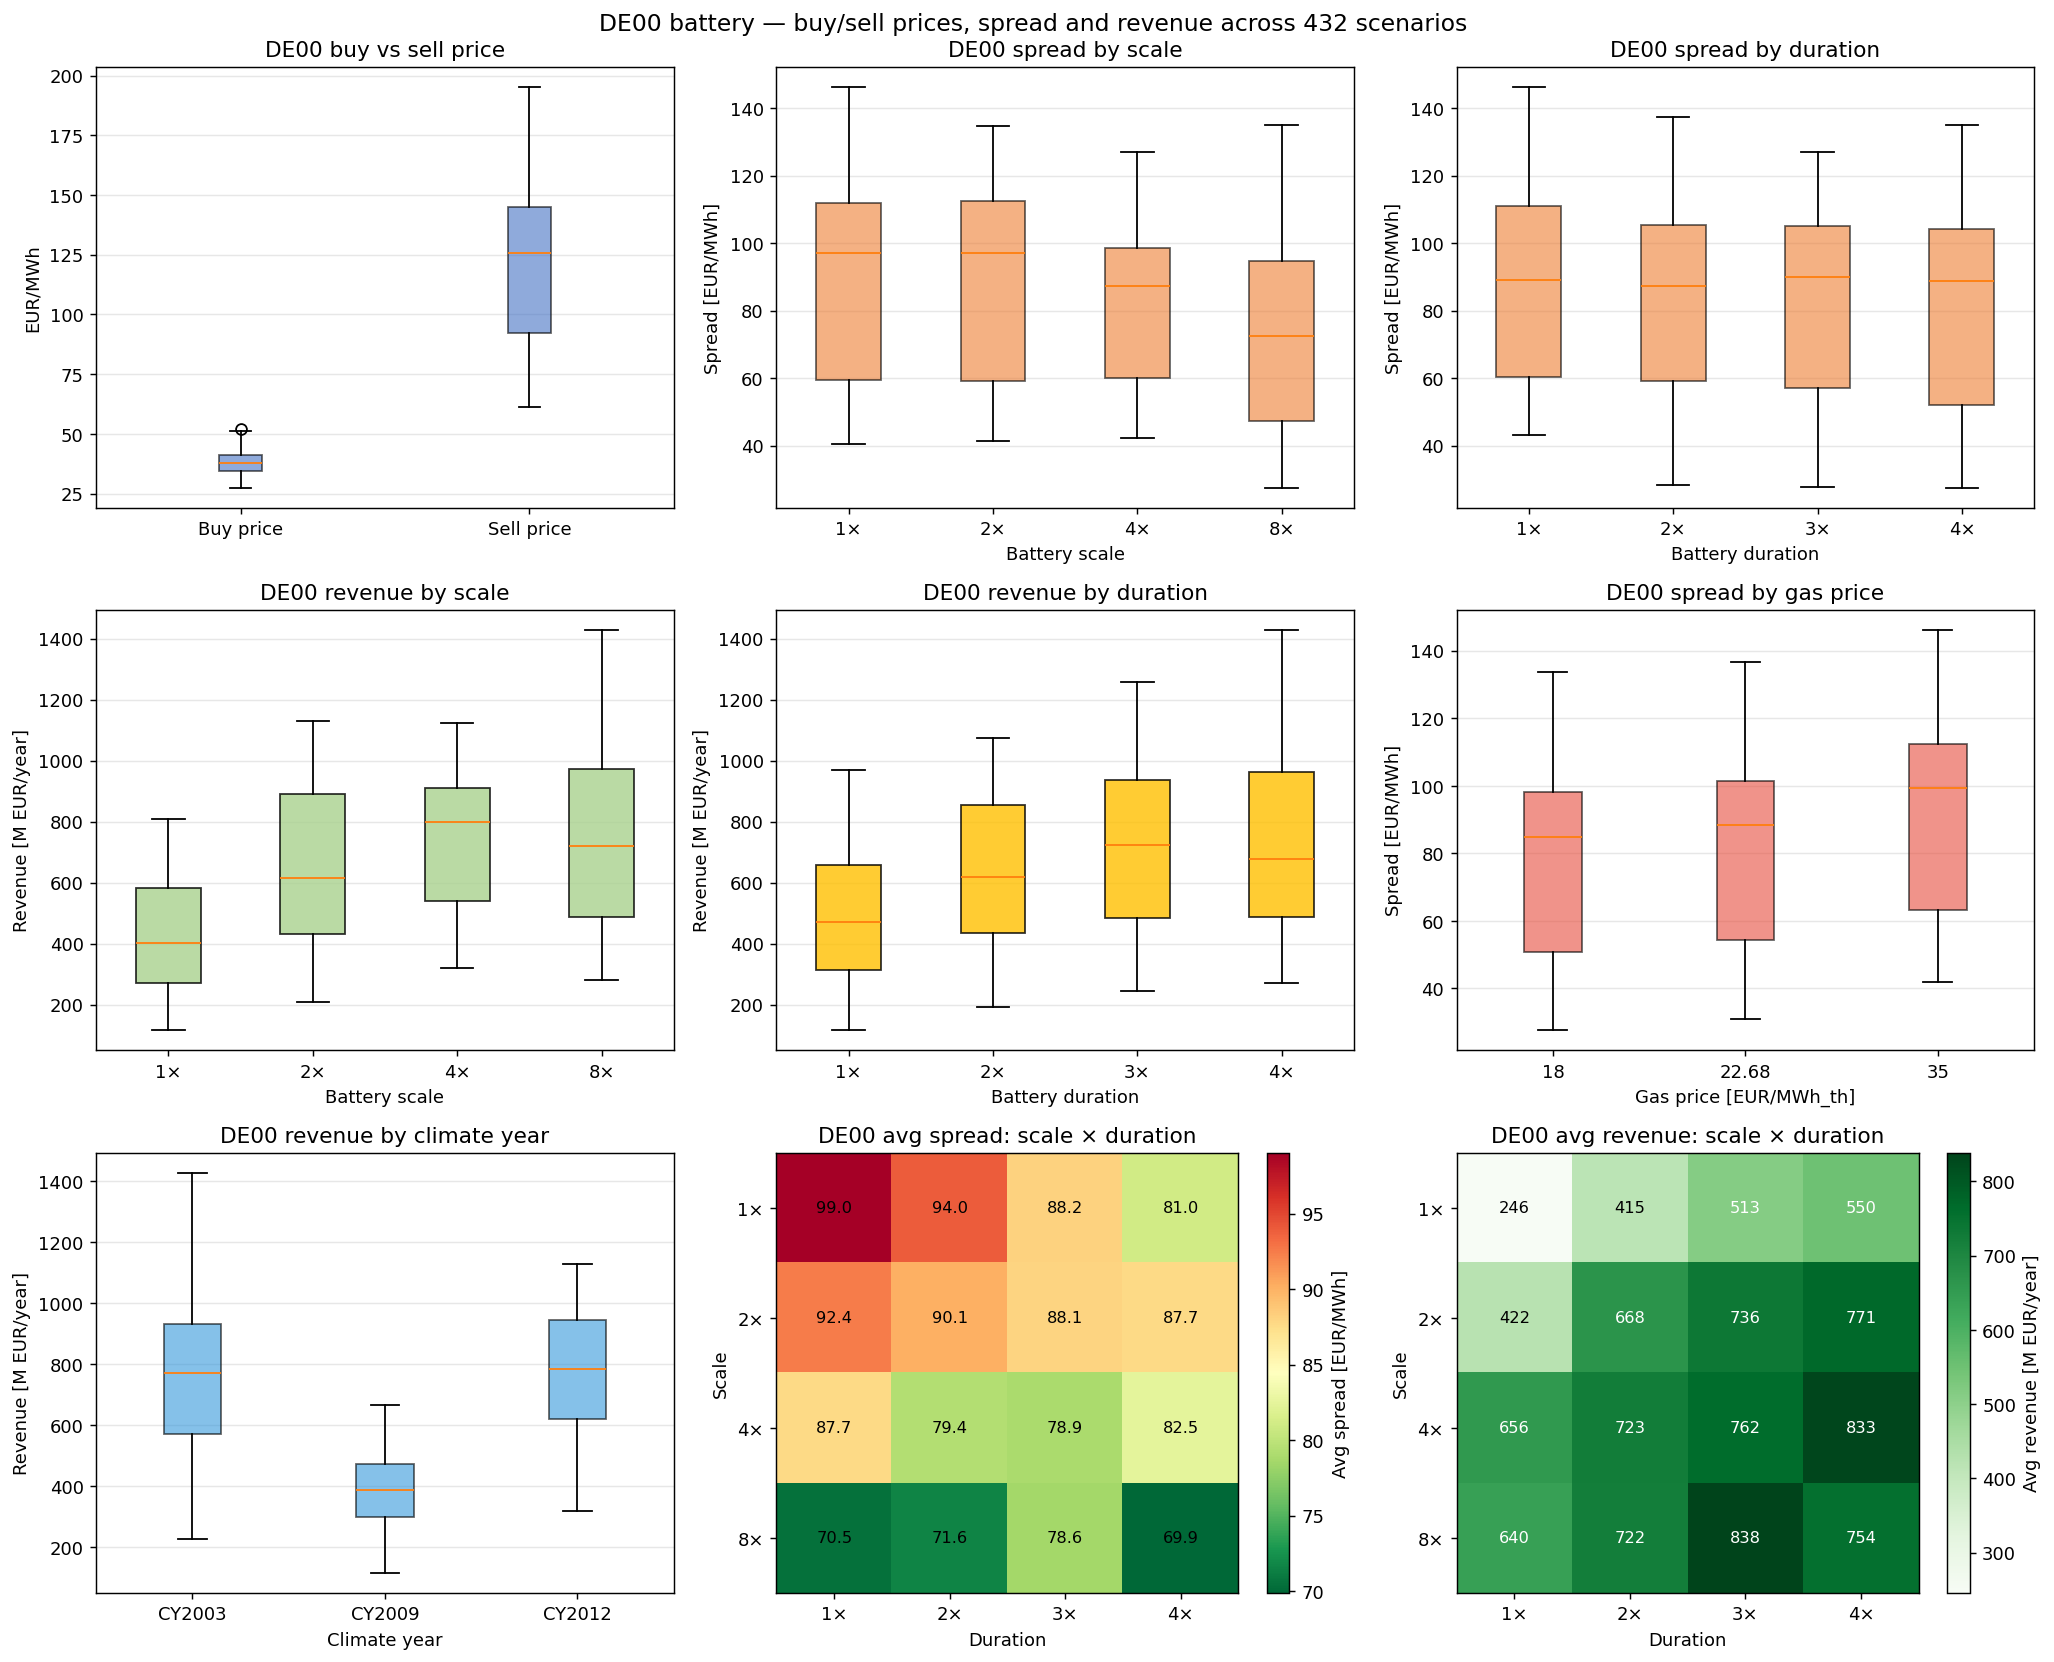

In [38]:
bdf = bat_de  # shorthand
scales = [1, 2, 4, 8]
durations = [1, 2, 3, 4]
gas_prices = [18, 22.68, 35]
cys = [2003, 2009, 2012]

fig, axes = plt.subplots(3, 3, figsize=(16, 13))

ax = axes[0, 0]
ax.boxplot([bdf.buy_price.dropna(), bdf.sell_price.dropna()],
           labels=["Buy price", "Sell price"], patch_artist=True,
           boxprops=dict(facecolor="#4472c4", alpha=0.6))
ax.set_ylabel("EUR/MWh"); ax.set_title("DE00 buy vs sell price"); ax.grid(axis="y", alpha=0.3)

ax = axes[0, 1]
ax.boxplot([bdf[bdf.bat_scale==s]["spread"].dropna() for s in scales],
           labels=[f"{s}×" for s in scales], patch_artist=True,
           boxprops=dict(facecolor="#ed7d31", alpha=0.6))
ax.set_xlabel("Battery scale"); ax.set_ylabel("Spread [EUR/MWh]")
ax.set_title("DE00 spread by scale"); ax.grid(axis="y", alpha=0.3)

ax = axes[0, 2]
ax.boxplot([bdf[bdf.bat_duration==d]["spread"].dropna() for d in durations],
           labels=[f"{d}×" for d in durations], patch_artist=True,
           boxprops=dict(facecolor="#ed7d31", alpha=0.6))
ax.set_xlabel("Battery duration"); ax.set_ylabel("Spread [EUR/MWh]")
ax.set_title("DE00 spread by duration"); ax.grid(axis="y", alpha=0.3)

ax = axes[1, 0]
ax.boxplot([bdf[bdf.bat_scale==s]["revenue_meur"].dropna() for s in scales],
           labels=[f"{s}×" for s in scales], patch_artist=True,
           boxprops=dict(facecolor="#a9d18e", alpha=0.8))
ax.set_xlabel("Battery scale"); ax.set_ylabel("Revenue [M EUR/year]")
ax.set_title("DE00 revenue by scale"); ax.grid(axis="y", alpha=0.3)

ax = axes[1, 1]
ax.boxplot([bdf[bdf.bat_duration==d]["revenue_meur"].dropna() for d in durations],
           labels=[f"{d}×" for d in durations], patch_artist=True,
           boxprops=dict(facecolor="#ffc000", alpha=0.8))
ax.set_xlabel("Battery duration"); ax.set_ylabel("Revenue [M EUR/year]")
ax.set_title("DE00 revenue by duration"); ax.grid(axis="y", alpha=0.3)

ax = axes[1, 2]
ax.boxplot([bdf[bdf.gas_price==g]["spread"].dropna() for g in gas_prices],
           labels=[str(g) for g in gas_prices], patch_artist=True,
           boxprops=dict(facecolor="#e74c3c", alpha=0.6))
ax.set_xlabel("Gas price [EUR/MWh_th]")
ax.set_ylabel("Spread [EUR/MWh]")
ax.set_title("DE00 spread by gas price"); ax.grid(axis="y", alpha=0.3)

ax = axes[2, 0]
ax.boxplot([bdf[bdf.climate_year==cy]["revenue_meur"].dropna() for cy in cys],
           labels=[f"CY{cy}" for cy in cys], patch_artist=True,
           boxprops=dict(facecolor="#3498db", alpha=0.6))
ax.set_xlabel("Climate year"); ax.set_ylabel("Revenue [M EUR/year]")
ax.set_title("DE00 revenue by climate year"); ax.grid(axis="y", alpha=0.3)

ax = axes[2, 1]
matrix = np.array([[bdf[(bdf.bat_scale==s)&(bdf.bat_duration==d)]["spread"].mean()
                    for d in durations] for s in scales])
im = ax.imshow(matrix, cmap="RdYlGn_r", aspect="auto")
plt.colorbar(im, ax=ax, label="Avg spread [EUR/MWh]")
ax.set_xticks(range(len(durations))); ax.set_yticks(range(len(scales)))
ax.set_xticklabels([f"{d}×" for d in durations])
ax.set_yticklabels([f"{s}×" for s in scales])
ax.set_xlabel("Duration"); ax.set_ylabel("Scale")
ax.set_title("DE00 avg spread: scale × duration")
for i in range(len(scales)):
    for j in range(len(durations)):
        ax.text(j, i, f"{matrix[i,j]:.1f}", ha="center", va="center", fontsize=9)

ax = axes[2, 2]
matrix_rev = np.array([[bdf[(bdf.bat_scale==s)&(bdf.bat_duration==d)]["revenue_meur"].mean()
                        for d in durations] for s in scales])
im2 = ax.imshow(matrix_rev, cmap="Greens", aspect="auto")
plt.colorbar(im2, ax=ax, label="Avg revenue [M EUR/year]")
ax.set_xticks(range(len(durations))); ax.set_yticks(range(len(scales)))
ax.set_xticklabels([f"{d}×" for d in durations])
ax.set_yticklabels([f"{s}×" for s in scales])
ax.set_xlabel("Duration"); ax.set_ylabel("Scale")
ax.set_title("DE00 avg revenue: scale × duration")
for i in range(len(scales)):
    for j in range(len(durations)):
        ax.text(j, i, f"{matrix_rev[i,j]:.0f}", ha="center", va="center", fontsize=9,
                color="white" if matrix_rev[i,j] > matrix_rev.max()*0.6 else "black")

fig.suptitle(f"DE00 battery — buy/sell prices, spread and revenue across 432 scenarios", fontsize=13)
plt.tight_layout()
plt.show()


## Section 10 — Battery Hourly Charging Profile (Europe-wide)

Representative subset: gas=22.68 €/MWh_th, co2=113.4 €/tCO₂, duration=2×, all bat_scales (1/2/4/8×) × all climate years (2003/2009/2012) = **12 networks**.

`storage_units_t.p` convention: positive = discharge, negative = charge.

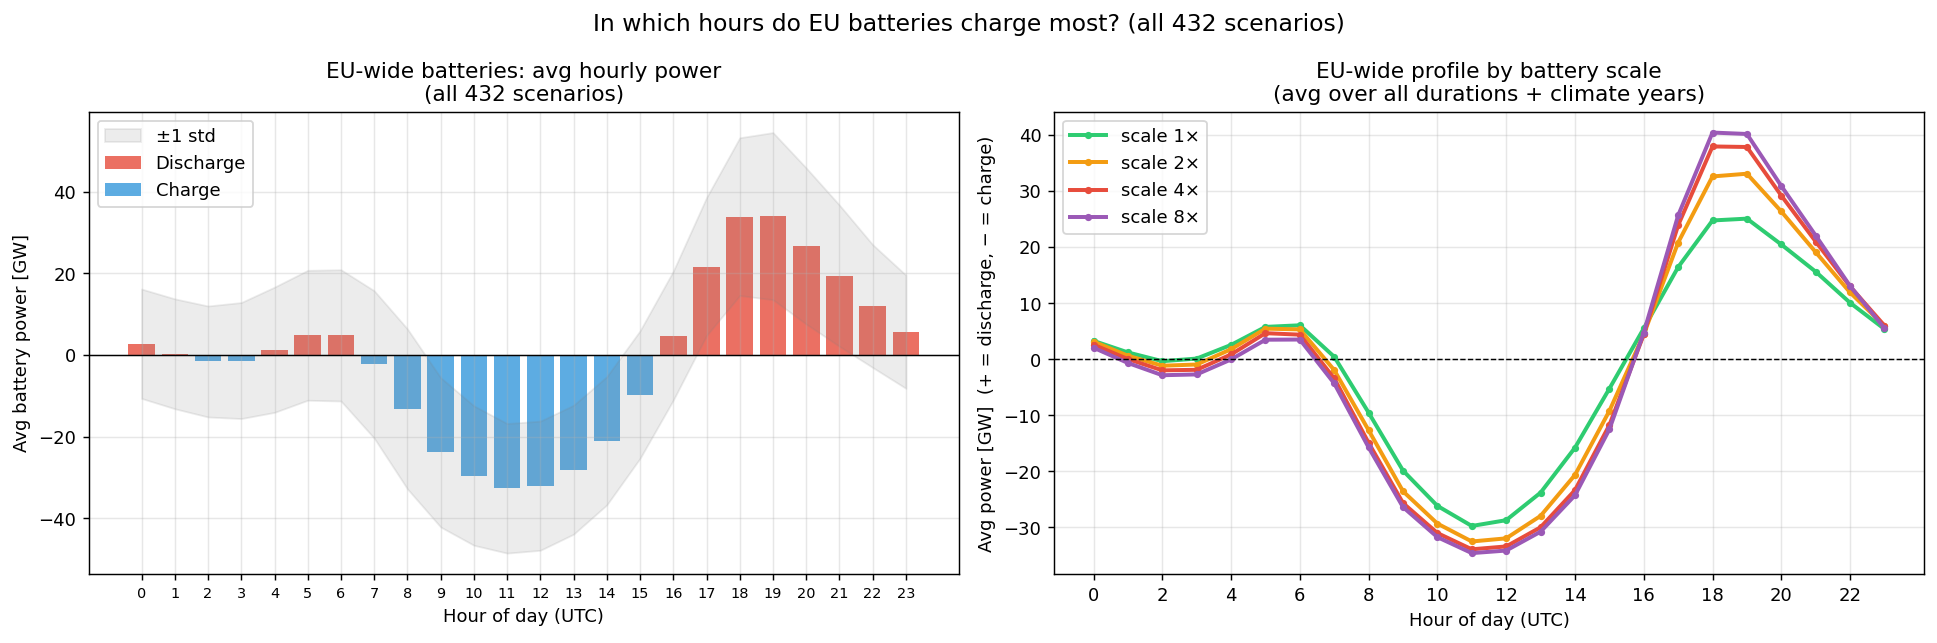


Peak CHARGE hour:    11h → -32.7 GW
Peak DISCHARGE hour: 19h → 34.0 GW


In [39]:
# EU-wide hourly battery charging profile — all 432 scenarios from parquet
bat_p_eu = storage_p_raw[["tag", "timestamp"] + bat_cols].copy()
bat_p_eu["p_eu"] = bat_p_eu[bat_cols].sum(axis=1) / 1e3  # GW
bat_p_eu["hour"] = bat_p_eu["timestamp"].dt.hour

# Add scenario metadata
bat_p_eu = bat_p_eu.merge(res[["tag", "bat_scale", "climate_year"]], on="tag")

# Average hourly profile across ALL 432 scenarios
hourly_all = bat_p_eu.groupby("hour")["p_eu"].mean()
hourly_std = bat_p_eu.groupby("hour")["p_eu"].std()

# Average hourly profile by bat_scale (averaged over all other dims)
hourly_by_scale = bat_p_eu.groupby(["bat_scale", "hour"])["p_eu"].mean().unstack(level=0)

hours = np.arange(24)
scale_colors = {1: "#2ecc71", 2: "#f39c12", 4: "#e74c3c", 8: "#9b59b6"}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.bar(hours, hourly_all.clip(lower=0).values, color="#e74c3c", alpha=0.8, label="Discharge")
ax.bar(hours, hourly_all.clip(upper=0).values, color="#3498db", alpha=0.8, label="Charge")
ax.fill_between(hours,
                (hourly_all - hourly_std).values,
                (hourly_all + hourly_std).values,
                alpha=0.15, color="grey", label="±1 std")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Hour of day (UTC)")
ax.set_ylabel("Avg battery power [GW]")
ax.set_title("EU-wide batteries: avg hourly power\n(all 432 scenarios)")
ax.legend()
ax.grid(alpha=0.3)
ax.set_xticks(hours)
ax.set_xticklabels(hours, fontsize=8)

ax = axes[1]
for scale, color in scale_colors.items():
    if scale in hourly_by_scale.columns:
        ax.plot(hours, hourly_by_scale[scale].values, color=color, linewidth=2.2,
                marker="o", markersize=3, label=f"scale {scale}×")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Hour of day (UTC)")
ax.set_ylabel("Avg power [GW]  (+ = discharge, − = charge)")
ax.set_title("EU-wide profile by battery scale\n(avg over all durations + climate years)")
ax.legend()
ax.grid(alpha=0.3)
ax.set_xticks(range(0, 24, 2))

fig.suptitle("In which hours do EU batteries charge most? (all 432 scenarios)", fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nPeak CHARGE hour:    {hourly_all.idxmin()}h → {hourly_all.min():.1f} GW")
print(f"Peak DISCHARGE hour: {hourly_all.idxmax()}h → {hourly_all.max():.1f} GW")

## Section 10b — Battery Hourly Charging Profile (DE00 only)

Same subset as above (12 networks). Battery units filtered to `bus == "DE00"` only.

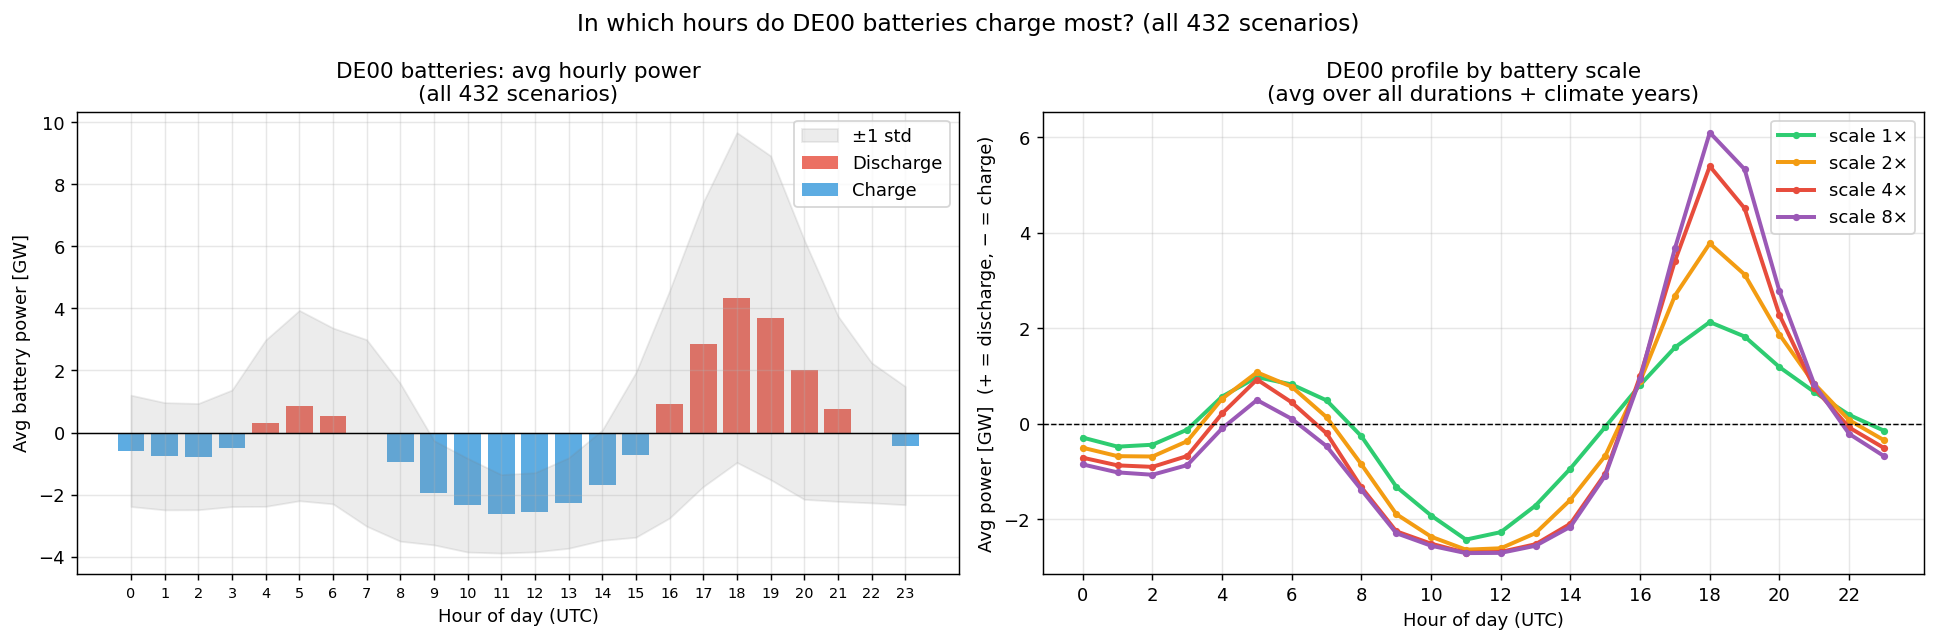


DE00 peak CHARGE hour:    11h → -2620 MW
DE00 peak DISCHARGE hour: 18h → 4348 MW


In [40]:
# DE00 hourly battery charging profile — all 432 scenarios from parquet
BUS_H = "DE00"

bat_p_de = storage_p_raw[["tag", "timestamp"] + de00_bat_cols].copy()
bat_p_de["p_de00"] = bat_p_de[de00_bat_cols].sum(axis=1) / 1e3  # GW
bat_p_de["hour"] = bat_p_de["timestamp"].dt.hour
bat_p_de = bat_p_de.merge(res[["tag", "bat_scale", "climate_year"]], on="tag")

hourly_de_all   = bat_p_de.groupby("hour")["p_de00"].mean()
hourly_de_std   = bat_p_de.groupby("hour")["p_de00"].std()
hourly_de_scale = bat_p_de.groupby(["bat_scale", "hour"])["p_de00"].mean().unstack(level=0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.bar(hours, hourly_de_all.clip(lower=0).values, color="#e74c3c", alpha=0.8, label="Discharge")
ax.bar(hours, hourly_de_all.clip(upper=0).values, color="#3498db", alpha=0.8, label="Charge")
ax.fill_between(hours,
                (hourly_de_all - hourly_de_std).values,
                (hourly_de_all + hourly_de_std).values,
                alpha=0.15, color="grey", label="±1 std")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Hour of day (UTC)")
ax.set_ylabel("Avg battery power [GW]")
ax.set_title(f"{BUS_H} batteries: avg hourly power\n(all 432 scenarios)")
ax.legend()
ax.grid(alpha=0.3)
ax.set_xticks(hours)
ax.set_xticklabels(hours, fontsize=8)

ax = axes[1]
for scale, color in scale_colors.items():
    if scale in hourly_de_scale.columns:
        ax.plot(hours, hourly_de_scale[scale].values, color=color, linewidth=2.2,
                marker="o", markersize=3, label=f"scale {scale}×")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Hour of day (UTC)")
ax.set_ylabel("Avg power [GW]  (+ = discharge, − = charge)")
ax.set_title(f"{BUS_H} profile by battery scale\n(avg over all durations + climate years)")
ax.legend()
ax.grid(alpha=0.3)
ax.set_xticks(range(0, 24, 2))

fig.suptitle(f"In which hours do {BUS_H} batteries charge most? (all 432 scenarios)", fontsize=13)
plt.tight_layout()
plt.show()

print(f"\n{BUS_H} peak CHARGE hour:    {hourly_de_all.idxmin()}h → {hourly_de_all.min()*1e3:.0f} MW")
print(f"{BUS_H} peak DISCHARGE hour: {hourly_de_all.idxmax()}h → {hourly_de_all.max()*1e3:.0f} MW")

## Section 11 — How Batteries Reduce Price Volatility

Representative subset: gas=22.68, co2=113.4, dur=2×, all bat_scales × all climate years.

Three panels:
1. **Price Duration Curve** — 8760 LMP values sorted descending; batteries flatten extremes
2. **Hourly LMP profile** — avg LMP by hour of day; batteries shave morning/evening peaks
3. **LMP std deviation vs bat_scale** — quantitative measure of volatility reduction

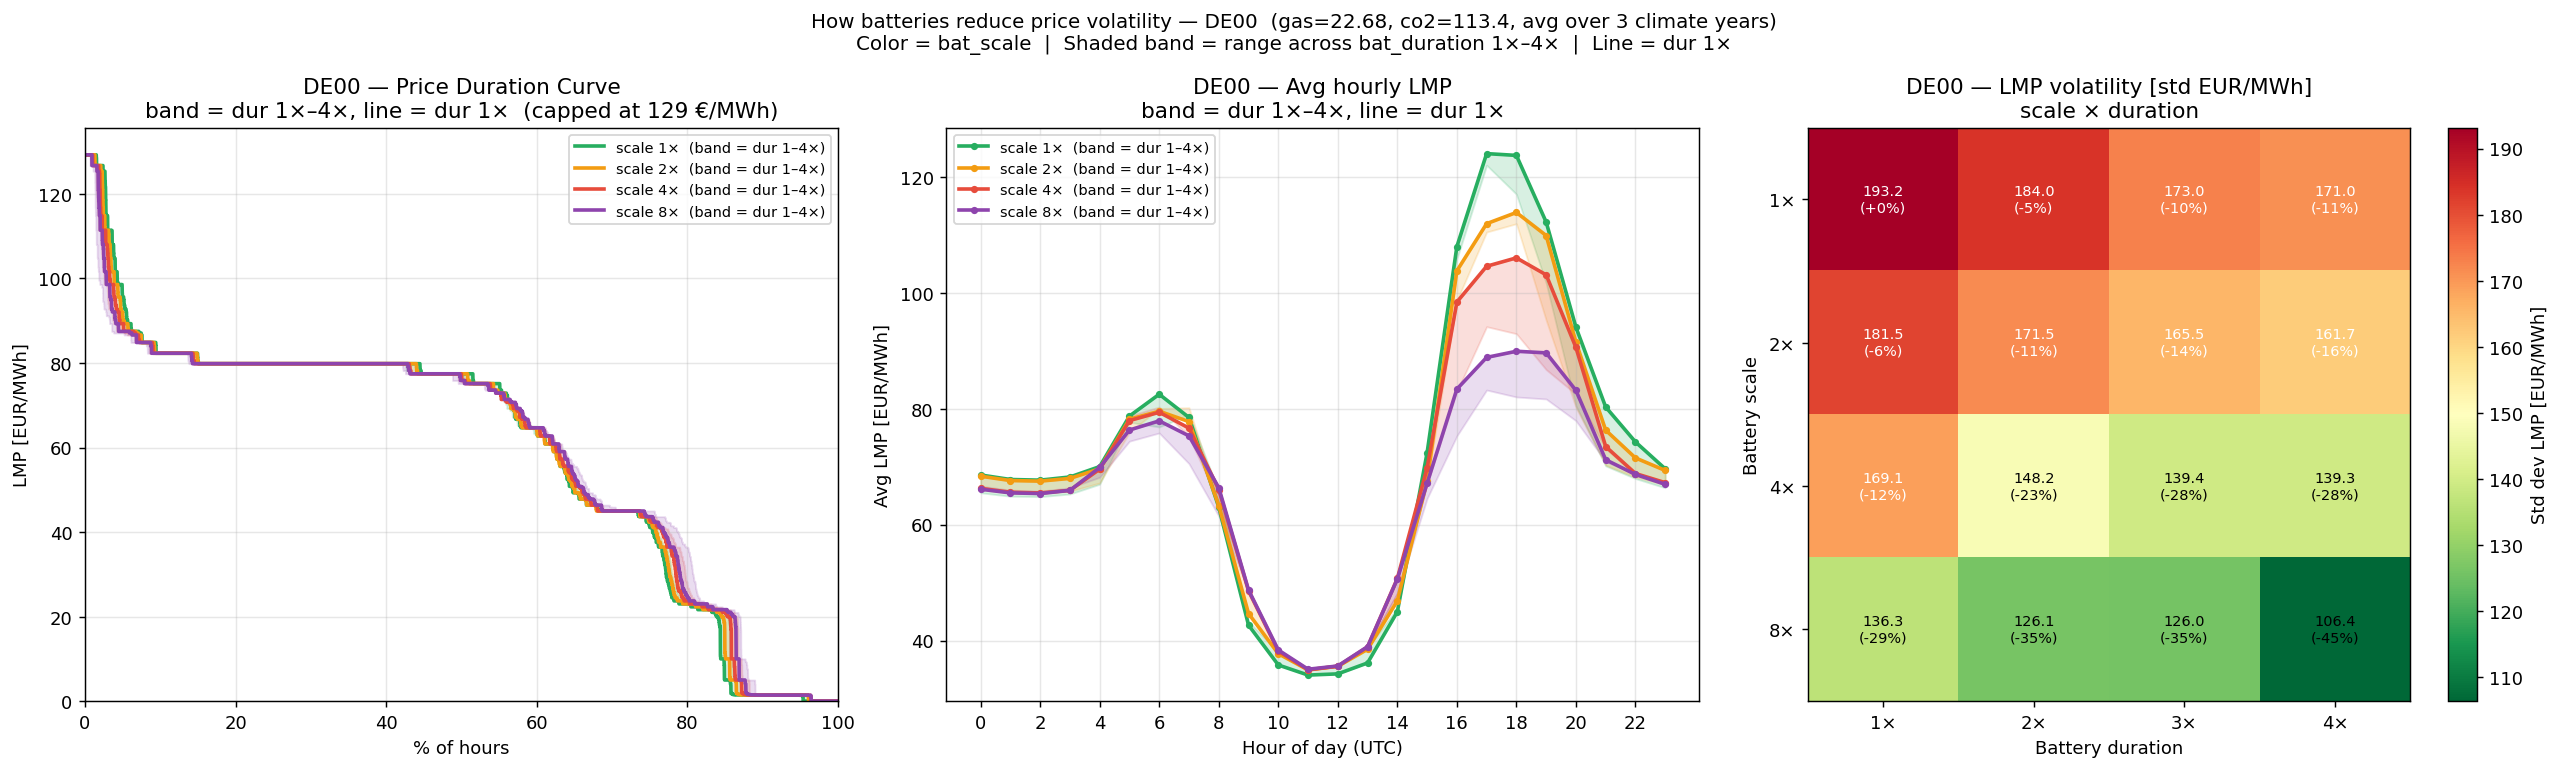

In [45]:
BUS_V     = "DE00"
SCALES    = [1, 2, 4, 8]
DURATIONS = [1, 2, 3, 4]
FIX_GAS   = 22.68
FIX_CO2   = 113.4

scale_colors = {1: "#27ae60", 2: "#f39c12", 4: "#e74c3c", 8: "#8e44ad"}

sub16 = res[
    (res.gas_price == FIX_GAS) & (res.co2_price == FIX_CO2)
][["tag", "bat_scale", "bat_duration", "climate_year"]].copy()

lmp_16 = lmp_raw[lmp_raw["tag"].isin(sub16["tag"])][["tag", "timestamp", BUS_V]].copy()
lmp_16 = lmp_16.merge(sub16, on="tag")
lmp_16["hour"] = lmp_16["timestamp"].dt.hour

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Panel 1: Price Duration Curve with shaded bands ---
ax = axes[0]
all_vals_pdc = lmp_16[BUS_V].values
pdc_cap = np.percentile(all_vals_pdc[np.isfinite(all_vals_pdc)], 99)  # clip extreme slack prices

for s in SCALES:
    color = scale_colors[s]
    curves = {}
    for d in DURATIONS:
        vals = lmp_16[(lmp_16.bat_scale == s) & (lmp_16.bat_duration == d)][BUS_V].values
        curves[d] = np.sort(vals)[::-1]
    n = min(len(v) for v in curves.values())
    x = np.linspace(0, 100, n)
    lo  = np.minimum(curves[1][:n], pdc_cap)
    hi  = np.minimum(curves[4][:n], pdc_cap)
    mid = np.minimum(curves[1][:n], pdc_cap)  # line = dur 1×
    ax.fill_between(x, lo, hi, color=color, alpha=0.18)
    ax.plot(x, mid, color=color, linewidth=2, label=f"scale {s}×  (band = dur 1–4×)")

ax.set_xlabel("% of hours")
ax.set_ylabel("LMP [EUR/MWh]")
ax.set_title(f"{BUS_V} — Price Duration Curve\nband = dur 1×–4×, line = dur 1×  (capped at {pdc_cap:.0f} €/MWh)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.set_xlim(0, 100)
ax.set_ylim(bottom=0, top=pdc_cap * 1.05)

# --- Panel 2: Avg hourly LMP with shaded bands ---
ax = axes[1]
hours = np.arange(24)
for s in SCALES:
    color = scale_colors[s]
    hourly = {}
    for d in DURATIONS:
        hourly[d] = lmp_16[(lmp_16.bat_scale == s) & (lmp_16.bat_duration == d)].groupby("hour")[BUS_V].mean().values
    ax.fill_between(hours, hourly[1], hourly[4], color=color, alpha=0.18)
    ax.plot(hours, hourly[1], color=color, linewidth=2, marker="o", markersize=3,
            label=f"scale {s}×  (band = dur 1–4×)")

ax.set_xlabel("Hour of day (UTC)")
ax.set_ylabel("Avg LMP [EUR/MWh]")
ax.set_title(f"{BUS_V} — Avg hourly LMP\nband = dur 1×–4×, line = dur 1×")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.set_xticks(range(0, 24, 2))

# --- Panel 3: Std heatmap scale × duration ---
ax = axes[2]
std_matrix = np.zeros((len(SCALES), len(DURATIONS)))
for i, s in enumerate(SCALES):
    for j, d in enumerate(DURATIONS):
        vals = lmp_16[(lmp_16.bat_scale == s) & (lmp_16.bat_duration == d)][BUS_V]
        std_matrix[i, j] = vals.std()

im = ax.imshow(std_matrix, cmap="RdYlGn_r", aspect="auto")
plt.colorbar(im, ax=ax, label="Std dev LMP [EUR/MWh]")
ax.set_xticks(range(len(DURATIONS)))
ax.set_yticks(range(len(SCALES)))
ax.set_xticklabels([f"{d}×" for d in DURATIONS])
ax.set_yticklabels([f"{s}×" for s in SCALES])
ax.set_xlabel("Battery duration")
ax.set_ylabel("Battery scale")
ax.set_title(f"{BUS_V} — LMP volatility [std EUR/MWh]\nscale × duration")

base = std_matrix[0, 0]
for i in range(len(SCALES)):
    for j in range(len(DURATIONS)):
        pct = (std_matrix[i, j] - base) / base * 100
        ax.text(j, i, f"{std_matrix[i,j]:.1f}\n({pct:+.0f}%)",
                ha="center", va="center", fontsize=8,
                color="white" if std_matrix[i,j] > std_matrix.mean() else "black")

fig.suptitle(
    f"How batteries reduce price volatility — {BUS_V}  (gas={FIX_GAS}, co2={FIX_CO2}, avg over 3 climate years)\n"
    f"Color = bat_scale  |  Shaded band = range across bat_duration 1×–4×  |  Line = dur 1×",
    fontsize=11
)
plt.tight_layout()
plt.show()